<a href="https://colab.research.google.com/github/chascaldini/mvp_ml_met_tags_acervo/blob/main/notebook/mvp_machine_learning_met.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação textual e técnicas de NLP para apoio à catalogação e sugestão de descritores em acervos culturais: um estudo com o Met Open Access

## MVP de Machine Learning (Sprint 3)
**Autora**: Charlyne Scaldini  
**Matrícula**: 4052025001595  
**Instituição**: PUC-Rio | Pós-Graduação em Data Science & Analytics  
**Ano**: 2026  

---------------------------------------------------
### Índice do projeto

**1. Introdução e definição do problema**  
**2. Preparação do ambiente**  
**3. Dados e análise exploratória**  
**4. Definição do target e seleção de features**  
**5. Pré-processamento, vetorização e pipeline de classificação**  
**6. Modelos e validação**  
**7. Avaliação detalhada do modelo LinearSVC**  
**8. Otimização simples de hiperparâmetros**  
**9. Exploração semântica complementar com Word2Vec**  
**10. Conclusão**  



# 1 Introdução e definição do problema

Acervos culturais dependem de metadados para organizar, descrever e recuperar informações sobre obras, objetos e documentos. Entre esses metadados, os descritores temáticos desempenham papel fundamental ao permitir a identificação de assuntos, conceitos e características relevantes dos registros.

Mas até que ponto os próprios metadados de uma obra são capazes de revelar esses descritores?

Este projeto investiga essa questão por meio da aplicação de técnicas de Machine Learning e Processamento de Linguagem Natural (PLN) ao dataset Open Access do Metropolitan Museum of Art (The Met). A proposta consiste em avaliar se informações presentes em campos como título, material, tipologia e contexto institucional contêm padrões suficientes para apoiar a sugestão automática de descritores.

Além de explorar um problema clássico de classificação textual supervisionada, o estudo dialoga diretamente com desafios relacionados à catalogação, indexação e recuperação da informação em acervos culturais, buscando compreender como técnicas computacionais podem contribuir para processos de organização do conhecimento e apoio à tomada de decisão.


## 1.1 Contexto: Met Open Access

O Metropolitan Museum of Art (The Met), fundado em 1870 e localizado em Nova York, é uma das principais instituições museológicas do mundo, reunindo obras de diferentes períodos históricos, culturas e regiões geográficas. Por meio da iniciativa Open Access, o museu disponibiliza publicamente metadados e imagens de obras em domínio público sob licença CC0, incentivando pesquisas, experimentações e aplicações baseadas em dados culturais.

O dataset utilizado neste projeto reúne aproximadamente 485 mil registros de objetos da coleção do museu, incluindo informações técnicas, históricas e descritivas sobre obras de diferentes períodos, materiais, tipologias e contextos culturais.

Para além de seu valor institucional, a base apresenta características particularmente interessantes para o problema investigado neste estudo. Cada obra está associada a diferentes campos descritivos produzidos durante processos de catalogação e documentação, além de descritores temáticos utilizados para representar seu conteúdo.

Esse conjunto de informações torna o acervo um ambiente adequado para investigar se padrões presentes nos metadados textuais são suficientes para apoiar a sugestão automática de descritores, aproximando técnicas de Machine Learning e Processamento de Linguagem Natural (PLN) de desafios relacionados à organização e recuperação da informação em acervos culturais.


## 1.2 Escopo e objetivo

O presente estudo investiga a viabilidade da classificação supervisionada aplicada à sugestão de descritores em acervos culturais. Para isso, utiliza registros do Metropolitan Museum of Art (The Met) e avalia se informações presentes em campos descritivos das obras podem ser utilizadas para prever categorias temáticas previamente atribuídas ao acervo.

A modelagem é construída a partir dos campos `Title`, `Medium`, `Object Name`, `Classification` e `Department`, combinados em uma representação textual única e transformados em vetores por meio da técnica TF-IDF. Sobre essa representação são avaliados diferentes algoritmos de classificação supervisionada, incluindo Multinomial Naive Bayes, Logistic Regression e LinearSVC.

Como complemento à etapa principal de classificação, o projeto realiza uma exploração semântica com Word2Vec para investigar relações de proximidade entre termos presentes nos metadados. Essa análise busca ampliar a discussão sobre possíveis aplicações de técnicas de NLP em atividades relacionadas à catalogação, indexação, enriquecimento de metadados e recuperação da informação em acervos culturais.



## 1.3 Definição do problema de classificação textual

O problema central deste MVP consiste em treinar modelos capazes de prever Tags associadas às obras do acervo a partir de seus metadados textuais.

Em termos práticos, o projeto busca investigar se padrões presentes em campos como títulos, materiais, classificações e outras informações descritivas permitem sugerir automaticamente palavras-chave relacionadas aos objetos da coleção.

Para isso, os textos são transformados em representações numéricas utilizando a técnica TF-IDF (Term Frequency–Inverse Document Frequency), permitindo que algoritmos de classificação supervisionada aprendam relações entre os termos presentes nos registros e as Tags associadas às obras.

Como exploração complementar, é utilizada a técnica Word2Vec para analisar relações semânticas entre palavras recorrentes do acervo, discutindo possíveis aplicações futuras em recomendação de descritores, catalogação e recuperação da informação.

## 1.4 Relevância para acervos culturais, catalogação, indexação e recuperação da informação

A organização e a recuperação da informação em acervos culturais dependem fortemente da qualidade dos metadados e da consistência dos processos de indexação. Em instituições culturais, a atribuição manual de palavras-chave e descritores costuma demandar tempo, conhecimento especializado e padronização terminológica contínua.

Nesse contexto, técnicas de classificação textual apoiadas por Processamento de Linguagem Natural (PLN) podem atuar como ferramentas de apoio à catalogação, auxiliando na sugestão automatizada de Tags relacionadas ao conteúdo dos registros. Embora não substituam a revisão humana, essas abordagens podem contribuir para acelerar processos de descrição, reduzir inconsistências e ampliar as possibilidades de recuperação da informação em bases documentais e museológicas.

Além de explorar uma aplicação prática para acervos culturais, este projeto busca aproximar conceitos de Machine Learning das atividades de catalogação, indexação e organização da informação, investigando como essas técnicas podem apoiar profissionais responsáveis pela descrição e mediação de coleções.

# 2 Preparação do ambiente

Nesta etapa, são configuradas as dependências do projeto e importadas as bibliotecas necessárias para manipulação, análise e visualização dos dados, bem como as ferramentas utilizadas no pré-processamento textual, na vetorização dos textos, na modelagem supervisionada e na avaliação dos modelos de classificação.

## 2.1 Configuração do ambiente

Nesta etapa são importadas as bibliotecas utilizadas ao longo do projeto, garantindo a organização e a reprodutibilidade do ambiente de desenvolvimento.

As dependências incluem ferramentas para manipulação e visualização de dados, pré-processamento textual, vetorização com TF-IDF, treinamento de modelos supervisionados e avaliação de desempenho.



In [1]:
# Instalação de bibliotecas adicionais
!pip install -q missingno
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.4 MB/s eta 0:00:00


In [2]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np
import missingno as msno
import re

# Visualização de dados
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Ignorar warnings
import warnings
warnings.filterwarnings("ignore")


## 2.2 Bibliotecas para Machine Learning e classificação textual

A seguir, são importadas as bibliotecas utilizadas nas etapas de pré-processamento textual, vetorização dos textos, construção dos pipelines de classificação, treinamento dos modelos supervisionados e avaliação dos resultados.


In [3]:
# Divisão treino/teste
from sklearn.model_selection import train_test_split

# Validação cruzada e otimização
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# Representação textual TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Renderização de tabelas HTML no notebook
from IPython.display import HTML

# Imports necessários para a abordagem com ColumnTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Pipeline e transformações
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.preprocessing import FunctionTransformer

# Modelos de classificação
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2.3 Configuração de reprodutibilidade

Para garantir consistência nos resultados obtidos ao longo das execuções, foi definida uma semente aleatória (`random_state`). Essa configuração permite reproduzir divisões de treino e teste e outros processos que dependem de aleatoriedade.


In [4]:
# Definição da seed global
SEED = 42

# Configuração do NumPy
np.random.seed(SEED)

## 2.4 Bibliotecas para exploração semântica

Além da etapa principal de classificação textual supervisionada, o projeto inclui uma exploração complementar com Word2Vec para investigar relações semânticas entre termos recorrentes do acervo.

In [5]:
# Word2Vec
from gensim.models import Word2Vec

# 3 Dados e análise exploratória

Esta seção apresenta as etapas relacionadas à compreensão e exploração do dataset utilizado no projeto. Além da carga e inspeção inicial dos dados, são discutidos o contexto institucional da base, a justificativa de sua escolha e as principais características estruturais relevantes para o problema de classificação textual investigado neste estudo.



## 3.1 Fonte de dados e carga do dataset

O dataset utilizado neste estudo foi disponibilizado pelo Metropolitan Museum of Art (The Met) por meio da iniciativa Open Access, que oferece acesso público a metadados e imagens de obras em domínio público sob licença CC0.

Os dados estão disponíveis no repositório oficial da iniciativa:

https://github.com/metmuseum/openaccess

O arquivo `MetObjects.csv`, utilizado neste trabalho, reúne aproximadamente 485 mil registros relacionados às obras da coleção do museu.




In [6]:
# URL do dataset
url = "https://media.githubusercontent.com/media/metmuseum/openaccess/refs/heads/master/MetObjects.csv"

# Carregamento do dataset
df = pd.read_csv(url)

## 3.2 Características do dataset

O dataset reúne registros de objetos pertencentes a diferentes períodos históricos, culturas, departamentos e categorias da coleção do museu. Essa diversidade resulta em uma base heterogênea, composta por atributos com diferentes níveis de preenchimento, granularidade e detalhamento descritivo.

Do ponto de vista analítico, a base combina informações estruturadas e textuais, permitindo explorar tanto características catalográficas dos registros quanto padrões linguísticos presentes nos metadados.

Essas características tornam o conjunto de dados adequado para investigações envolvendo classificação textual e organização da informação em acervos culturais.


## 3.3 Justificativa da escolha do dataset

O dataset do Met Open Access foi escolhido por reunir características compatíveis com os objetivos deste estudo. Além de sua ampla dimensão e diversidade temática, a base disponibiliza metadados estruturados e textuais associados a objetos culturais de diferentes períodos, contextos e categorias.

Outro fator relevante é a presença de Tags previamente atribuídas aos registros, permitindo a construção de um problema de classificação supervisionada para investigação da sugestão automática de descritores.

Por fim, trata-se de uma base pública, amplamente documentada e disponibilizada por uma instituição de referência, favorecendo a reprodutibilidade do projeto e a aplicação dos métodos em um contexto próximo ao encontrado em acervos culturais reais.


## 3.4 Estrutura geral do dataset

O dataset é composto por aproximadamente 485 mil registros e 54 colunas contendo informações administrativas, históricas, geográficas e descritivas sobre os objetos da coleção.

Os campos disponíveis incluem:

* identificadores institucionais;
* informações de autoria;
* datas;
* localização geográfica;
* classificações;
* descrições textuais;
* tags associadas às obras.

Essa variedade de atributos fornece diferentes fontes de informação para a etapa de seleção de variáveis e para a construção dos modelos de classificação.


## 3.5 Inspeção inicial dos dados

Após a carga do dataset, é realizada uma inspeção inicial para compreender a dimensão da base, os tipos de dados presentes e a estrutura geral das colunas disponíveis.

Essa etapa permite obter uma visão geral do conjunto de dados e identificar atributos potencialmente relevantes para as análises posteriores, servindo como ponto de partida para a exploração e seleção das variáveis do projeto.



In [7]:
# Dimensão do dataset
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 484956
Quantidade de colunas: 54


In [8]:
# Informações gerais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 54 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Object Number            484956 non-null  object 
 1   Is Highlight             484956 non-null  bool   
 2   Is Timeline Work         484956 non-null  bool   
 3   Is Public Domain         484956 non-null  bool   
 4   Object ID                484956 non-null  int64  
 5   Gallery Number           49541 non-null   object 
 6   Department               484956 non-null  object 
 7   AccessionYear            481094 non-null  object 
 8   Object Name              482690 non-null  object 
 9   Title                    456153 non-null  object 
 10  Culture                  208190 non-null  object 
 11  Period                   91143 non-null   object 
 12  Dynasty                  23201 non-null   object 
 13  Reign                    11236 non-null   object 
 14  Port

In [9]:
# Visualização aleatória de registros
df.sample(5)

,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
312762,1975.1.1989,False,False,True,461481,NaN,Robert Lehman Collection,1975.0,Chair,"Side chair (Sgabello, pair with 1975.1.1990)",...,NaN,Woodwork-Furniture,NaN,http://www.metmuseum.org/art/collection/search...,NaN,NaN,"Metropolitan Museum of Art, New York, NY",Masks,http://vocab.getty.edu/page/aat/300262834,https://www.wikidata.org/wiki/Q161524
215295,69.675.4,False,False,False,346573,NaN,Drawings and Prints,1969.0,Book,Les Bains de Bade,...,NaN,Books,NaN,http://www.metmuseum.org/art/collection/search...,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
463405,45.78.7,False,False,True,815012,NaN,Drawings and Prints,1945.0,Print,The Holy Family,...,NaN,Prints,NaN,http://www.metmuseum.org/art/collection/search...,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
141181,74.51.2209,False,False,True,241762,NaN,Greek and Roman Art,1874.0,Lamp,Terracotta oil lamp,...,NaN,Terracottas,NaN,http://www.metmuseum.org/art/collection/search...,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
339074,"89.4.3348a, b",False,False,True,504753,NaN,Musical Instruments,1889,Regal,Regal,...,NaN,Aerophone-Organ,NaN,http://www.metmuseum.org/art/collection/search...,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN


A inspeção inicial confirma que o dataset foi carregado corretamente, contendo aproximadamente 485 mil registros distribuídos em 54 colunas. Cada registro corresponde a um objeto da coleção do Metropolitan Museum of Art, reunindo informações administrativas, históricas, geográficas e descritivas sobre as obras.

A análise estrutural da base evidencia a predominância de atributos textuais, além da presença de informações categóricas, temporais e geográficas. Essa diversidade de dados sugere diferentes possibilidades de exploração analítica e fornece uma visão inicial da riqueza informacional presente no acervo.

A partir dessa caracterização preliminar, as próximas etapas aprofundam a análise da qualidade dos dados, da distribuição das variáveis e da seleção dos atributos mais relevantes para o problema de classificação proposto.


## 3.6 Análise exploratória de dados (EDA)

Após a inspeção inicial do dataset completo, a análise exploratória concentra-se nas colunas consideradas mais relevantes para o problema de classificação textual proposto neste estudo.

A seleção dessas variáveis foi orientada tanto pelos resultados da exploração inicial dos dados quanto pelo potencial informacional dos campos para representar características das obras em processos de catalogação, indexação e recuperação da informação. Dessa forma, a EDA busca compreender a qualidade, distribuição e estrutura dos atributos candidatos à modelagem.

Os resultados desta etapa servirão de base para a definição da variável alvo, a seleção das features, as decisões de pré-processamento e a construção dos modelos de classificação apresentados nos capítulos seguintes.


### 3.6.1 Pré-seleção das colunas candidatas do projeto

A pré-seleção das variáveis foi realizada com base na análise exploratória dos dados e no potencial semântico dos campos disponíveis para apoiar a tarefa de classificação de descritores.

Além dos aspectos observados durante a EDA, a seleção considerou o contexto do problema e conhecimentos relacionados à organização da informação em acervos culturais. Foram priorizados campos capazes de descrever características das obras, materiais, tipologias e contextos institucionais, por representarem fontes de informação frequentemente utilizadas em processos de catalogação, indexação e recuperação da informação.

Nessa etapa, o objetivo não foi identificar relações estatísticas com a variável alvo, mas selecionar atributos que, do ponto de vista documental e descritivo, apresentassem potencial para contribuir com a modelagem supervisionada.


### 3.6.2 Dicionário resumido das variáveis candidatas

A tabela a seguir apresenta uma descrição resumida das variáveis pré-selecionadas para a etapa de modelagem. O objetivo é facilitar a compreensão dos atributos considerados na modelagem e documentar seu papel no processo de classificação.

| Variável         | Tipo       | Descrição                                                                         |
| ---------------- | ---------- | --------------------------------------------------------------------------------- |
| `Title`          | Textual    | Título da obra ou objeto                                                          |
| `Medium`         | Textual    | Materiais e técnicas utilizados                                                   |
| `Object Name`    | Textual    | Tipo ou denominação do objeto                                                     |
| `Classification` | Categórica | Classificação institucional atribuída à obra                                      |
| `Department`     | Categórica | Departamento responsável pela obra no museu                                       |
| `Tags`           | Textual    | Palavras-chave associadas ao registro; utilizada para construção da variável-alvo |


A análise dessas variáveis servirá de base para as etapas seguintes de exploração, seleção de atributos e construção dos modelos de classificação.

### 3.6.3 Estrutura das colunas candidatas

Nesta etapa é realizada uma análise estrutural das principais colunas pré selecionadas para o treinamento dos modelos de classificação textual.

A exploração inclui a verificação dos tipos de dados, volume de preenchimento, quantidade de valores únicos e exemplos de conteúdo das variáveis candidatas, buscando compreender sua relevância e adequação ao problema proposto.



In [10]:
# Definição das colunas candidatas à modelagem
cols_candidatas = [
    "Title",
    "Medium",
    "Object Name",
    "Classification",
    "Department",
    "Tags"
]

# Verificação de existência das colunas no dataset
colunas_faltantes = [col for col in cols_candidatas if col not in df.columns]

if colunas_faltantes:
    print("Colunas não encontradas no dataset:")
    print(colunas_faltantes)
else:
    print("Todas as colunas candidatas foram encontradas no dataset.")

Todas as colunas candidatas foram encontradas no dataset.


In [11]:
# Criação de um dataframe auxiliar apenas com as colunas candidatas
df_cols = df[cols_candidatas].copy()

# Visualização da primeira linha
df_cols.head(1)

,Title,Medium,Object Name,Classification,Department,Tags
0,One-dollar Liberty Head Coin,Gold,Coin,NaN,The American Wing,NaN


In [12]:
# Informações gerais das colunas candidatas
df_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Title           456153 non-null  object
 1   Medium          477741 non-null  object
 2   Object Name     482690 non-null  object
 3   Classification  406239 non-null  object
 4   Department      484956 non-null  object
 5   Tags            192455 non-null  object
dtypes: object(6)
memory usage: 22.2+ MB


In [13]:
# Exploração textual de registros aleatórios das colunas candidatas
df_cols.sample(
    n=min(5, len(df_cols)),
    random_state=SEED
)

,Title,Medium,Object Name,Classification,Department,Tags
312762,"Side chair (Sgabello, pair with 1975.1.1990)","Walnut, carved.",Chair,Woodwork-Furniture,Robert Lehman Collection,Masks
215295,Les Bains de Bade,"Verge d'Arches, 476/1200, wood engravings",Book,Books,Drawings and Prints,NaN
463405,The Holy Family,Engraving,Print,Prints,Drawings and Prints,NaN
141181,Terracotta oil lamp,Terracotta,Lamp,Terracottas,Greek and Roman Art,NaN
339074,Regal,"Wood, various",Regal,Aerophone-Organ,Musical Instruments,NaN


In [14]:
# Quantidade de valores únicos nas colunas candidatas
valores_unicos = (
    df_cols
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .reset_index()
)

valores_unicos.columns = ["Coluna", "Valores únicos"]

valores_unicos

,Coluna,Valores únicos
0,Title,245800
1,Medium,65907
2,Tags,44171
3,Object Name,28631
4,Classification,1244
5,Department,19


A análise das colunas candidatas evidencia a predominância de dados textuais (`object`) entre as variáveis selecionadas para o projeto, característica coerente com a proposta de classificação textual supervisionada adotada neste estudo.

Entre as variáveis analisadas, `Title`, `Medium` e `Object Name` apresentam elevado volume de preenchimento e alta diversidade terminológica, sugerindo potencial para capturar padrões descritivos relevantes para a previsão de Tags. Os exemplos observados nos registros demonstram a presença de informações relacionadas aos objetos, materiais e técnicas associados às obras.

A coluna `Tags`, definida inicialmente como variável-alvo do projeto, possui aproximadamente 44 mil valores únicos, evidenciando a diversidade dos termos de indexação presentes no acervo. Já `Classification` e `Department` apresentam menor cardinalidade, refletindo categorias institucionais mais controladas e padronizadas.

### 3.6.4 Valores ausentes

Como ocorre frequentemente em bases institucionais e museológicas, o dataset apresenta diferentes níveis de preenchimento entre suas variáveis.

Nesta etapa, são analisados os valores ausentes das colunas candidatas à modelagem, permitindo avaliar sua adequação ao problema proposto e subsidiar decisões relacionadas à seleção de atributos, filtragem dos registros e pré-processamento dos dados.

In [15]:
# Percentual de valores ausentes nas colunas principais
missing_percent = (
    df[cols_candidatas]
    .isnull()
    .mean()
    .sort_values(ascending=False) * 100
)

missing_percent

,0
Tags,60.314956
Classification,16.231782
Title,5.939302
Medium,1.487764
Object Name,0.467259
Department,0.000000


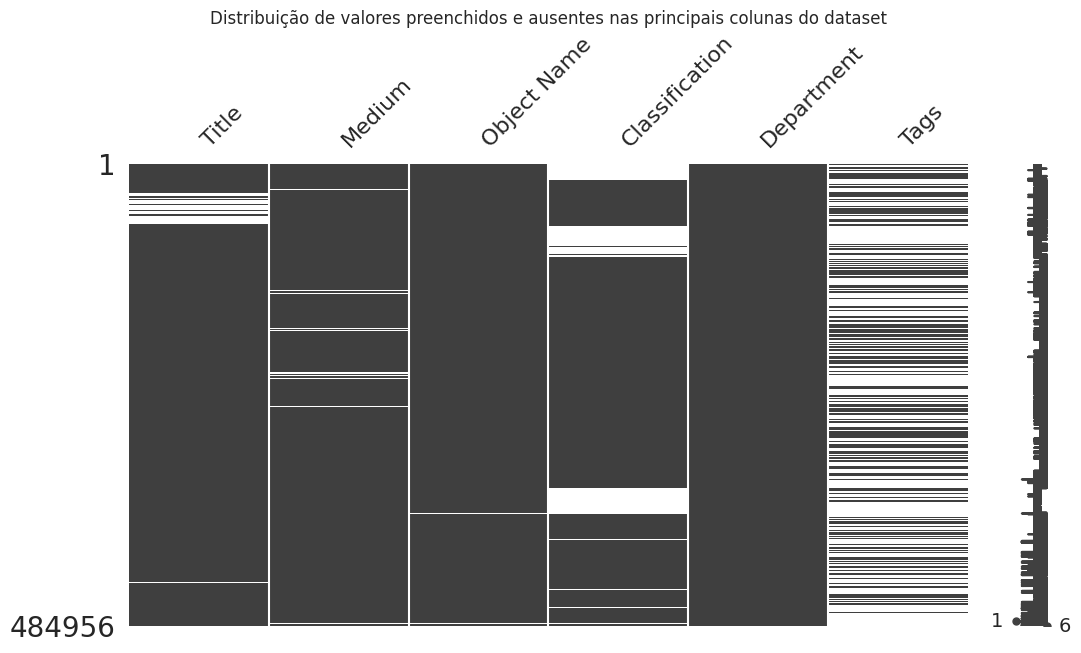

In [16]:
# Visualização gráfica de valores ausentes
msno.matrix(df[cols_candidatas], figsize=(12,6))
plt.title("Distribuição de valores preenchidos e ausentes nas principais colunas do dataset")
plt.show()

In [17]:
# Percentual de completude das colunas candidatas
completude = (
    df_cols
    .notna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

completude.columns = ["Coluna", "Completude (%)"]

completude

,Coluna,Completude (%)
0,Department,100.000000
1,Object Name,99.532741
2,Medium,98.512236
3,Title,94.060698
4,Classification,83.768218
5,Tags,39.685044


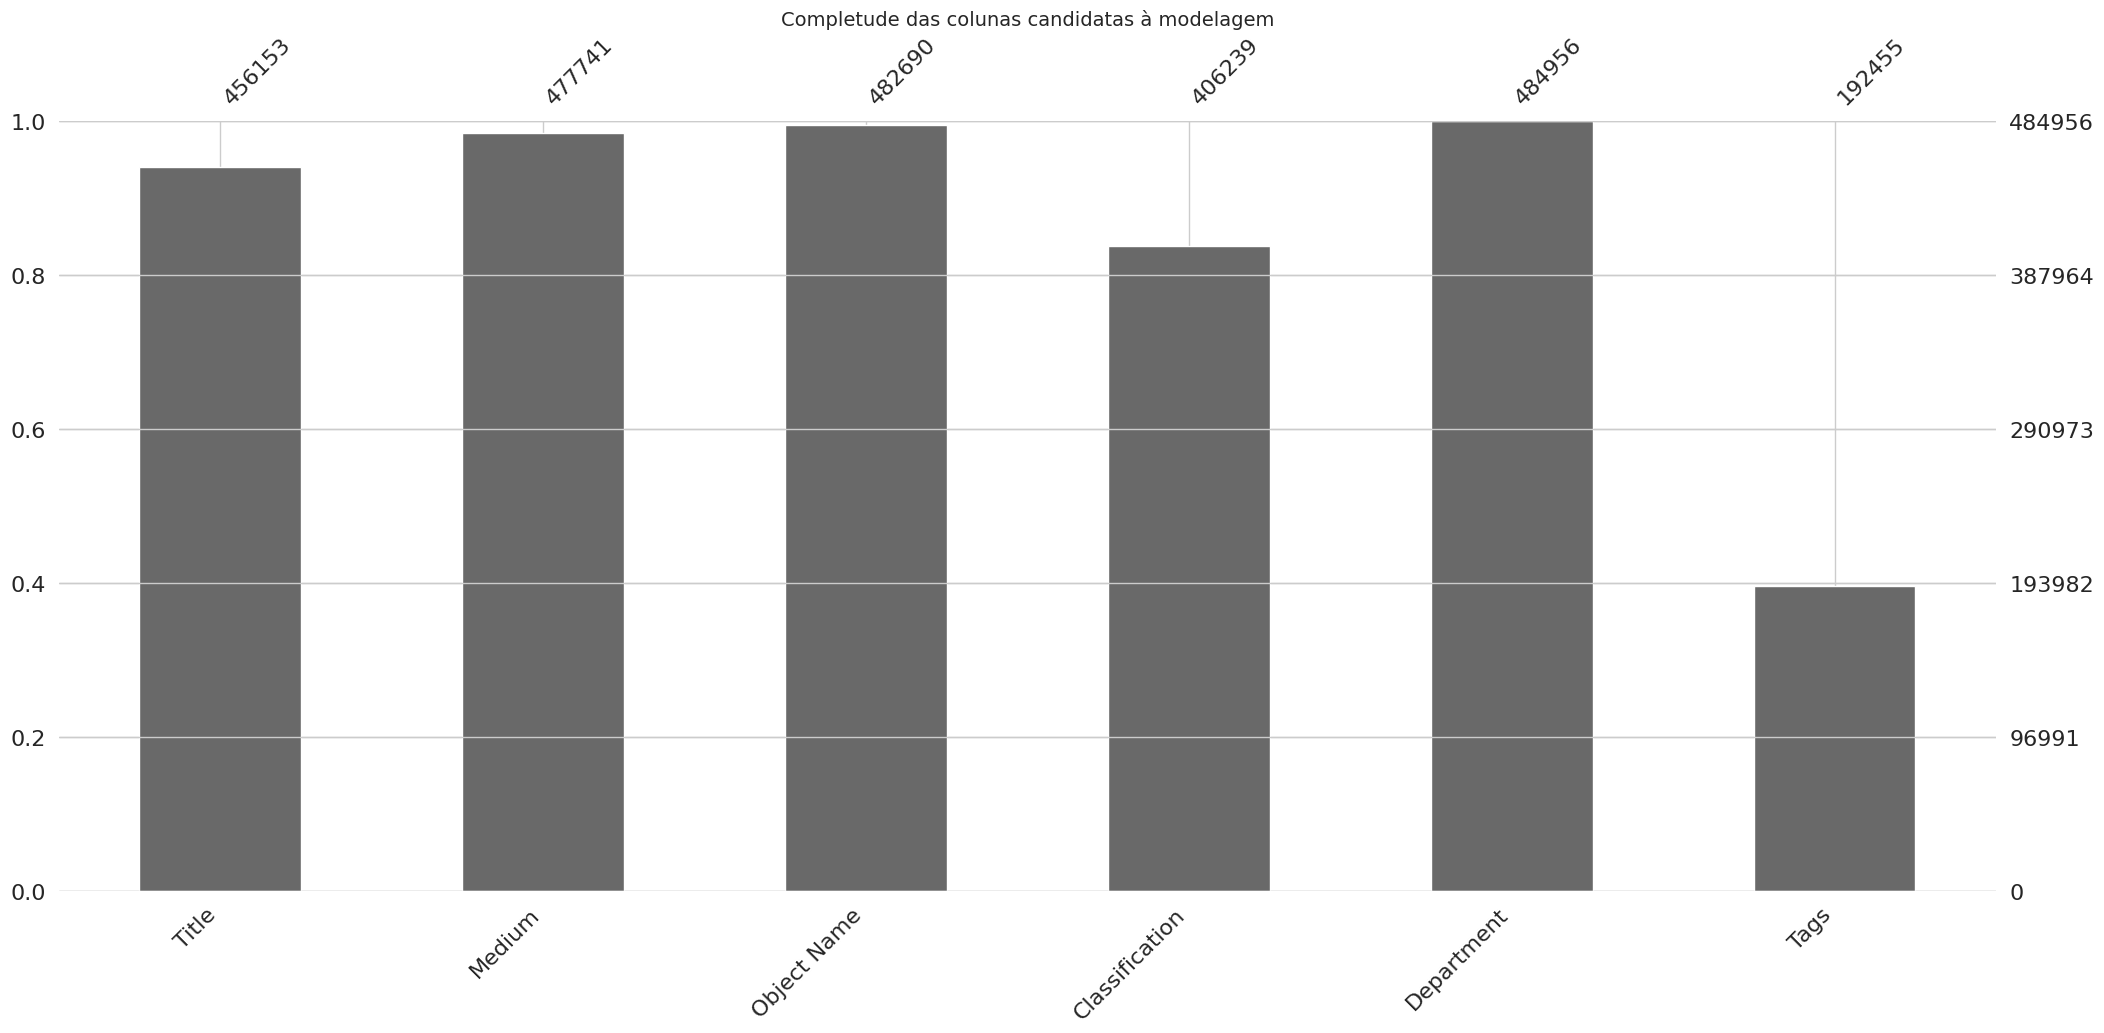

In [18]:
# Visualização da completude das colunas candidatas

plt.figure(figsize=(12,5))

msno.bar(
    df[
        [
            "Title",
            "Medium",
            "Object Name",
            "Classification",
            "Department",
            "Tags"
        ]
    ],
  )

plt.title(
    "Completude das colunas candidatas à modelagem",
    fontsize=14
)

plt.xticks(rotation=45)

plt.show()

A análise de valores ausentes revela diferenças importantes no nível de preenchimento das colunas candidatas ao projeto.

Entre as variáveis selecionadas, `Department` apresenta preenchimento completo, enquanto `Object Name`, `Medium` e `Title` também demonstram alta disponibilidade de dados, característica favorável para a construção dos modelos de classificação.

A coluna `Classification` possui aproximadamente 16% de valores ausentes, mas mantém volume suficiente de registros preenchidos para ser considerada nas etapas posteriores de modelagem.

Já a variável `Tags`, definida inicialmente como alvo do problema de classificação supervisionada, apresenta cerca de 60% de registros ausentes. Embora esse percentual seja elevado, o volume absoluto de registros preenchidos permanece expressivo, com aproximadamente 192 mil ocorrências disponíveis para treinamento e avaliação dos modelos.

De modo geral, os resultados evidenciam um cenário comum em bases culturais reais, nas quais diferentes níveis de descrição e indexação coexistem entre os registros do acervo.



### 3.6.5 Distribuição e exploração das variáveis candidatas à modelagem

Nesta etapa são exploradas as principais variáveis candidatas à modelagem, com foco na distribuição das categorias mais frequentes e nas características dos metadados selecionados para o projeto.

A análise busca compreender padrões recorrentes presentes nos registros do acervo, avaliar o comportamento da variável-alvo (`Tags`) e identificar aspectos relevantes para as etapas posteriores de seleção de atributos, pré-processamento e classificação supervisionada.

#### Variável alvo (`Tags`)

A análise da variável `Tags` busca compreender o volume de registros disponíveis para treinamento supervisionado, além da diversidade terminológica presente nas palavras-chave associadas às obras do acervo.

In [19]:
# Quantidade de registros com Tags preenchidas
tags_preenchidas = df["Tags"].notnull().sum()

# Percentual de preenchimento
percent_tags = (tags_preenchidas / len(df)) * 100

print(f"Registros com Tags: {tags_preenchidas:,}")
print(f"Percentual preenchido: {percent_tags:.2f}%")

Registros com Tags: 192,455
Percentual preenchido: 39.69%


In [20]:
# Registros com Tags preenchidas
df_tags = df[df["Tags"].notnull()].copy()

# Visualização de exemplos de Tags
df_tags["Tags"].sample(5, random_state=42)

,Tags
39302,Bamboo|Gods|Men|Deer|Turtles
207726,Men
203905,Men|Portraits
136221,Flowers|Leaves
332261,Men|Portraits


In [21]:
# Top Tags mais frequentes
top_tags = (
    df["Tags"]
    .value_counts()
    .head(20)
)

top_tags

,count
Tags,
Flowers,8543
Portraits|Women|Actresses,5612
Men|Portraits,5055
Men,5023
Men|Portraits|Baseball|Athletes,4125
Women,3692
Birds,2895
Flowers|Leaves,2593
Portraits|Women,2503


In [148]:
# Visualização das Tags mais frequentes

fig = px.bar(
    x=top_tags.values,
    y=top_tags.index,
    orientation="h",
    title="Visualização Tags mais frequentes no dataset",
    labels={
        "x": "Quantidade",
        "y": "Tags"
    }
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    xaxis_title="Quantidade",
    yaxis_title=""
)

fig.show()

A coluna `Tags` apresenta aproximadamente 192 mil registros preenchidos, correspondendo a cerca de 40% do dataset. Apesar da presença de valores ausentes, o volume disponível é suficiente para a construção do problema de classificação supervisionada proposto.

A análise das Tags evidencia grande diversidade temática no acervo, abrangendo descritores relacionados a pessoas, elementos naturais, arquitetura, paisagens e objetos culturais. Entre os termos mais frequentes destacam-se referências a retratos, figuras humanas, flores e elementos decorativos, indicando forte presença de aspectos visuais e iconográficos na representação das obras.

Também foi observado um cenário de desbalanceamento entre as categorias, com algumas Tags concentrando grande número de registros, enquanto muitas outras apresentam baixa frequência. Essa distribuição é característica de acervos culturais e representa um desafio para tarefas de classificação supervisionada.

Essas características motivaram decisões adotadas nas etapas seguintes do projeto, como a criação da variável `Tag_principal`, o recorte para as 100 Tags mais frequentes e a utilização de divisão estratificada entre treino e teste, buscando tornar o problema computacionalmente viável e preservar a distribuição das classes durante a modelagem.


#### Variável `Classification`

A análise da variável `Classification` busca compreender os principais tipos de objetos presentes no acervo e avaliar seu potencial como variável complementar para a modelagem textual.


In [23]:
# Seleção dos registros com Classification preenchido
df_classification = df[df["Classification"].notna()].copy()

# Quantidade e percentual de registros com Object Name preenchido
qtd_classification = df_classification.shape[0]
perc_classification = (qtd_classification / df.shape[0]) * 100

print(f"Registros com Classification preenchido: {qtd_classification:,}")
print(f"Percentual preenchido: {perc_classification:.2f}%")

Registros com Classification preenchido: 406,239
Percentual preenchido: 83.77%


In [24]:
# Distribuição das principais classificações
top_classification = (
    df["Classification"]
    .value_counts()
    .head(15)
)

top_classification

,count
Classification,
Prints,84326
Prints|Ephemera,29148
Photographs,27336
Drawings,23062
Vases,21302
Books,14779
Ceramics,11066
Textiles-Woven,10970
Photographs|Ephemera,10389


In [149]:
# Visualização das classificações mais frequentes

fig = px.bar(
    x=top_classification.values,
    y=top_classification.index,
    orientation="h",
    title="Classificações mais frequentes",
    labels={
        "x": "Quantidade",
        "y": "Classification"
    }
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    xaxis_title="Quantidade",
    yaxis_title=""
)

fig.show()

A distribuição da variável `Classification` evidencia diversidade tipológica no acervo do Met, com predominância de registros relacionados a impressos, fotografias, desenhos, vasos, livros e cerâmicas.

Também são observadas categorias compostas, como `Prints|Ephemera` e `Photographs|Ephemera`, indicando combinações classificatórias utilizadas na organização institucional dos objetos.

Sua menor cardinalidade em comparação com as variáveis textuais sugere um papel complementar na caracterização das obras, fornecendo informações categóricas potencialmente relevantes para o processo de classificação.


#### Variável `Department`

A análise da variável `Department` busca compreender a distribuição institucional das obras dentro do acervo do Met e avaliar seu possível potencial como variável complementar para a modelagem.

In [26]:
# Seleção dos registros com Department preenchido
df_department = df[df["Department"].notna()].copy()

# Quantidade e percentual de registros com Object Name preenchido
qtd_department = df_department.shape[0]
perc_department = (qtd_department / df.shape[0]) * 100

print(f"Registros com Department preenchido: {qtd_department:,}")
print(f"Percentual preenchido: {perc_department:.2f}%")

Registros com Department preenchido: 484,956
Percentual preenchido: 100.00%


In [27]:
# Departamentos mais frequentes
top_departments = (
    df["Department"]
    .value_counts()
    .head(15)
)

top_departments

,count
Department,
Drawings and Prints,172630
European Sculpture and Decorative Arts,43051
Photographs,37459
Asian Art,37000
Greek and Roman Art,33726
Costume Institute,31652
Egyptian Art,27969
The American Wing,18532
Islamic Art,15573


In [144]:
# Visualização dos departamentos mais frequentes
fig = px.bar(
    x=top_departments.values,
    y=top_departments.index,
    orientation="h",
    title="Departamentos mais frequentes",
    labels={
        "x": "Quantidade",
        "y": "Department"
    }
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    xaxis_title="Quantidade",
    yaxis_title=""
)

fig.show()

A distribuição da variável `Department` evidencia forte concentração de registros em departamentos relacionados a desenhos, gravuras, fotografia e artes decorativas, com destaque para `Drawings and Prints`, que representa a categoria mais frequente da base.

Também se observa ampla diversidade curatorial no acervo, incluindo departamentos dedicados à arte asiática, arte egípcia, instrumentos musicais, arte islâmica e arte moderna e contemporânea.

Por apresentar preenchimento completo e baixa cardinalidade, a variável fornece um contexto institucional complementar sobre as obras, contribuindo para a caracterização dos registros presentes na coleção.

#### Variável `Title`

A análise da variável `Title` busca compreender o potencial semântico dos títulos das obras e sua possível contribuição para o problema de classificação textual supervisionada.

In [29]:
# Seleção dos registros com título preenchido
df_title = df[df["Title"].notna()].copy()

# Quantidade e percentual de registros com título preenchido
qtd_title = df_title.shape[0]
perc_title = (qtd_title / df.shape[0]) * 100

print(f"Registros com Title preenchido: {qtd_title:,}")
print(f"Percentual preenchido: {perc_title:.2f}%")

Registros com Title preenchido: 456,153
Percentual preenchido: 94.06%


In [30]:
# Exemplos de Title junto com Tags
# Observando relações textuais entre o título da obra e as palavras-chave associadas

df_title[
    df_title["Tags"].notna()
][["Title", "Tags"]].sample(
    n=10,
    random_state=SEED
)

,Title,Tags
390388,"La Pratique de l'Aiguille, page 69 (recto)",Birds|Fruit|Flowers
461458,Hell Hounds Rallying Round the Idol of France,Satire|Napoleon I|Demons|Politics
419369,"Four of Hearts, from the Transparent Playing C...",Playing Cards
255724,"Conrad Celtis Presenting His Book ""Quatuor Lib...",Books|Men|Coat of Arms
15214,Four Figure Studies (from Sketchbook),Human Figures
152445,Carnelian scarab,Soldiers|Shields|Spears|Horses
245706,"Design for Landau, No. 3728",Carriages
186821,Female Figure,Women
102503,Portrait of Hans Count Wilczek,Men|Profiles
103788,Cup,Birds


In [31]:
# Análise exploratória das palavras mais frequentes em Title
# Aplicando limpeza textual leve apenas para visualização

# Stopwords adicionais pouco informativas no contexto do dataset
custom_stopwords = {
    "fragment",
    "series",
    "issued"
}

# União das stopwords padrão com as personalizadas
stopwords = ENGLISH_STOP_WORDS.union(custom_stopwords)

# Limpeza textual exploratória
title_words = (
    df_title["Title"]
    .dropna()
    .str.lower()
    .str.replace(r"[^a-zA-Z\s]", " ", regex=True)
    .str.split()
    .explode()
)

# Remoção de palavras curtas e stopwords
title_words = title_words[
    (title_words.str.len() > 2) &
    (~title_words.isin(stopwords))
]

# Frequência das palavras
top_title_words = (
    title_words
    .value_counts()
    .head(20)
    .reset_index()
)

# Renomeando colunas
top_title_words.columns = ["Palavra", "Frequência"]

# Visualização
top_title_words

,Palavra,Frequência
0,terracotta,19887
1,cigarettes,18889
2,cup,14612
3,plate,12998
4,drinking,12957
5,promote,10532
6,design,10451
7,new,10392
8,kylix,10072
9,actresses,9842


In [32]:
# Visualização das palavras mais frequentes em Title

fig = px.bar(
    top_title_words,
    x="Frequência",
    y="Palavra",
    orientation="h",
    title="Palavras mais frequentes no campo Title",
    text="Frequência"
)

# Ajuste da ordem para exibir as maiores frequências no topo
fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    xaxis_title="Frequência",
    yaxis_title=""
)

fig.show()

A coluna `Title` apresenta aproximadamente 456 mil registros preenchidos, correspondendo a mais de 94% do dataset, o que evidencia sua relevância para o problema de classificação proposto.

Os exemplos observados revelam grande diversidade temática nos títulos das obras, incluindo referências a retratos, objetos, cenas históricas, elementos decorativos e representações da natureza. Também é possível identificar relações intuitivas entre determinados termos presentes nos títulos e as Tags associadas aos registros.

Após uma etapa de limpeza textual leve, com remoção de stopwords e termos pouco informativos, a análise das palavras mais frequentes destaca vocábulos relacionados a objetos museológicos, materiais, utensílios e elementos decorativos, como `cup`, `plate`, `design`, `dress` e `bowl`. A presença de termos como `terracotta`, `kylix` e `cigarettes` também evidencia a diversidade tipológica e histórica do acervo.

Em conjunto, esses resultados sugerem que a variável `Title` concentra informações descritivas relevantes para a identificação de padrões associados às Tags das obras.

#### Variável `Medium`

A análise da variável `Medium` busca compreender o potencial descritivo dos materiais e técnicas associados às obras, avaliando sua possível contribuição para a classificação textual supervisionada.

In [33]:
# Seleção dos registros com Medium preenchido
df_medium = df[df["Medium"].notna()].copy()

# Quantidade e percentual de registros com Medium preenchido
qtd_medium = df_medium.shape[0]
perc_medium = (qtd_medium / df.shape[0]) * 100

print(f"Registros com Medium preenchido: {qtd_medium:,}")
print(f"Percentual preenchido: {perc_medium:.2f}%")

Registros com Medium preenchido: 477,741
Percentual preenchido: 98.51%


In [34]:
# Exemplos de Medium junto com Tags
# Observando possíveis relações semânticas entre materiais/técnicas e Tags

df_medium[
    df_medium["Tags"].notna()
][["Medium", "Tags"]].sample(
    n=10,
    random_state=SEED
)

,Medium,Tags
310561,Oil on oak panel,Portraits|Women
173645,Film negative,Houses
92499,"Linen, glass",Birds|Horses
290642,Engraving,God the Father|Adam|Eve
59747,Paper,Birds
169110,Film negative,Architecture|Buildings|Cities
118581,White marble,Men
368471,Engraving; first state of two (TIB),Men|Portraits
27726,Gold,Kings|Coins
265418,Etching,Ships


In [35]:
# Análise exploratória das palavras mais frequentes em Medium
# Aplicando limpeza textual leve apenas para visualização

# Stopwords adicionais pouco informativas no contexto do dataset
custom_stopwords_medium = {
    "ca",
    "cm",
    "x",
    "mounted",
    "overall"
}

# União das stopwords
stopwords_medium = ENGLISH_STOP_WORDS.union(custom_stopwords_medium)

# Limpeza textual exploratória
medium_words = (
    df_medium["Medium"]
    .dropna()
    .str.lower()
    .str.replace(r"[^a-zA-Z\s]", " ", regex=True)
    .str.split()
    .explode()
)

# Remoção de palavras curtas e stopwords
medium_words = medium_words[
    (medium_words.str.len() > 2) &
    (~medium_words.isin(stopwords_medium))
]

# Frequência das palavras
top_medium_words = (
    medium_words
    .value_counts()
    .head(20)
    .reset_index()
)

# Renomeando colunas
top_medium_words.columns = ["Palavra", "Frequência"]

# Visualização
top_medium_words

,Palavra,Frequência
0,etching,43279
1,silver,37544
2,lithograph,36955
3,color,36090
4,silk,35942
5,ink,35581
6,paper,34953
7,print,32059
8,engraving,31298
9,commercial,28914


In [36]:
# Visualização das palavras mais frequentes em Medium

fig = px.bar(
    top_medium_words,
    x="Frequência",
    y="Palavra",
    orientation="h",
    title="Palavras mais frequentes no campo Medium",
    text="Frequência"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    xaxis_title="Frequência",
    yaxis_title=""
)

fig.show()

A coluna `Medium` apresenta aproximadamente 478 mil registros preenchidos, correspondendo a mais de 98% do dataset, o que a torna uma das variáveis mais completas da base.

Os exemplos observados evidenciam informações sobre materiais, técnicas artísticas e processos de produção, incluindo termos como `oil on oak panel`, `engraving`, `film negative`, `white marble` e `gold`. Também é possível identificar relações entre determinados materiais e as Tags associadas às obras.

A análise das palavras mais frequentes revela forte presença de técnicas gráficas, materiais artísticos e suportes físicos, com destaque para termos como `etching`, `lithograph`, `silk`, `ink`, `paper`, `engraving` e `wood`. Também aparecem com frequência vocábulos ligados à fotografia e à reprodução gráfica, como `albumen`, `negative` e `print`, refletindo a diversidade material do acervo.

Os resultados indicam que a variável `Medium` reúne informações relevantes sobre a materialidade das obras, podendo contribuir para a identificação de padrões associados às Tags.


#### Variável `Object Name`

A análise da variável `Object Name` busca compreender os principais tipos de objetos presentes no acervo e avaliar seu potencial como variável descritiva complementar para a modelagem textual.

In [37]:
# Seleção dos registros com Object Name preenchido
df_object = df[df["Object Name"].notna()].copy()

# Quantidade e percentual de registros com Object Name preenchido
qtd_object = df_object.shape[0]
perc_object = (qtd_object / df.shape[0]) * 100

print(f"Registros com Object Name preenchido: {qtd_object:,}")
print(f"Percentual preenchido: {perc_object:.2f}%")

Registros com Object Name preenchido: 482,690
Percentual preenchido: 99.53%


In [38]:
# Quantidade de valores únicos em Object Name
object_unique = df_object["Object Name"].nunique()

print(f"Quantidade de valores únicos em Object Name: {object_unique:,}")

Quantidade de valores únicos em Object Name: 28,631


In [39]:
# Exemplos de Object Name junto com Tags
# Observando relações entre o tipo do objeto e as Tags associadas
df_object[
    df_object["Tags"].notna()
][["Object Name", "Tags"]].sample(
    n=10,
    random_state=SEED
)

,Object Name,Tags
231443,Drawing ; Ornament and architecture,Fireplaces|Interiors
15444,Drawing,Men
137613,Frieze fragment,Zodiac
107298,Roundel,Mary Magdalene
329932,Vase,Female Nudes|Dancing
461999,Print,Men|Portraits|Baseball|Athletes
232387,Drawing,Hats|Men
354354,Tweezers,Cosmetic Tools
228508,Print,Towns|Buildings|Children|Men|Dogs|Crowd|Christ...
182600,Photogram,Plants


In [40]:
# Frequência dos valores mais comuns em Object Name
top_object_names = (
    df_object["Object Name"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_object_names.columns = ["Object Name", "Frequência"]

top_object_names

,Object Name,Frequência
0,Print,102986
1,Photograph,29451
2,Drawing,26018
3,Book,13397
4,Kylix fragment,8926
5,Piece,8621
6,Fragment,7213
7,Painting,6014
8,Negative,5928
9,Bowl,3633


In [41]:
# Visualização dos Object Names mais frequentes

fig = px.bar(
    top_object_names,
    x="Frequência",
    y="Object Name",
    orientation="h",
    title="Object Names mais frequentes no dataset",
    text="Frequência"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    xaxis_title="Frequência",
    yaxis_title=""
)

fig.show()

A coluna `Object Name` apresenta aproximadamente 483 mil registros preenchidos, correspondendo a mais de 99% do dataset, o que a torna uma das variáveis mais completas da base.

Os exemplos observados evidenciam grande diversidade tipológica no acervo, incluindo objetos gráficos, escultóricos, arquitetônicos, fotográficos e utilitários. Também é possível identificar relações entre determinados tipos de objetos e as Tags associadas às obras, como representações humanas, arquitetura, esportes, plantas e elementos decorativos.

A análise das frequências mostra predominância de categorias relacionadas a impressos, fotografias, desenhos e livros, com destaque para `Print`, `Photograph`, `Drawing` e `Book`. Também aparecem com frequência fragmentos arqueológicos e objetos utilitários, como `Kylix fragment`, `Bowl`, `Vase` e `Plate`, refletindo a amplitude tipológica da coleção.

Os resultados indicam que a variável `Object Name` fornece informações relevantes sobre a natureza dos objetos catalogados, podendo contribuir para a identificação de padrões associados às Tags das obras.

#### Resultados da análise exploratória
A análise exploratória evidenciou que os campos selecionados apresentam boa disponibilidade de dados e características complementares para o problema proposto. Enquanto variáveis como Classification e Department fornecem contexto institucional e tipológico, campos como Title, Medium e Object Name acrescentam informações descritivas relevantes para a representação textual das obras. Em conjunto, esses resultados fundamentam a seleção das features e a definição da variável-alvo apresentadas na etapa seguinte.

# 4 Definição do target e seleção de features

Nesta etapa são definidas a variável-alvo (*target*) e as variáveis de entrada (*features*) utilizadas na modelagem supervisionada.

Também é realizada a separação dos dados em conjuntos de treino e teste, procedimento fundamental para avaliar o desempenho dos modelos em registros não utilizados durante o treinamento e reduzir o risco de vazamento de dados (*data leakage*).


## 4.1 Definição da variável-alvo (target)

A coluna `Tags` foi selecionada como base para a construção da variável alvo por representar os descritores temáticos associados às obras do acervo. Esses descritores desempenham papel importante em atividades de catalogação, indexação e recuperação da informação, contribuindo para a identificação de temas, objetos, pessoas, materiais e outros elementos relevantes para a descrição dos registros.

Considerando o objetivo deste MVP de investigar o potencial de técnicas de Machine Learning para apoio à catalogação, a tarefa proposta consiste em verificar se informações presentes em outros metadados textuais das obras são suficientes para prever os descritores associados a cada registro. Em outras palavras, busca-se avaliar se campos como título, material, tipologia e contexto institucional contêm sinais semânticos capazes de apoiar processos de sugestão automática de descritores.

Entretanto, a coluna `Tags` contém múltiplos descritores associados a uma mesma obra. Em diversos registros, diferentes termos coexistem em uma única observação, como em `Men|Portraits|Baseball|Athletes`, caracterizando um problema de classificação multilabel. Além disso, a variável apresenta elevada cardinalidade, com milhares de combinações possíveis ao longo do dataset, o que aumenta significativamente a complexidade da modelagem.

Para adequar o problema ao escopo deste MVP, foi criada uma variável alvo simplificada denominada `Tag_principal`, correspondente à primeira Tag associada a cada registro. Essa estratégia permitiu transformar o problema em uma tarefa de classificação multiclasse, mantendo a relação com os descritores originalmente atribuídos às obras e viabilizando o treinamento e a avaliação dos modelos no ambiente utilizado.

Por fim, foi aplicado um recorte contendo as 100 Tags mais frequentes da base, reduzindo a complexidade computacional do problema e concentrando a análise nas categorias com maior representatividade no acervo.


In [42]:
# Definição da coluna original de Tags
target_original = "Tags"

In [43]:
# Criação da variável alvo simplificada
df["Tag_principal"] = (
    df[target_original]
    .str.split("|")
    .str[0]
)

In [44]:
# Definição da quantidade de Tags mais frequentes utilizadas no MVP
top_n_tags = 100

In [45]:
# Seleção das Tags principais mais frequentes
tags_frequentes = (
    df["Tag_principal"]
    .value_counts()
    .head(top_n_tags)
    .index
)

In [46]:
# Filtragem do dataset
# Mantém apenas registros pertencentes às Top 100 Tags principais
df_model = df[
    df["Tag_principal"].isin(tags_frequentes)
].copy()

In [47]:
# Verificação do tamanho do dataset após filtragem
print(f"Quantidade de registros após filtro: {df_model.shape[0]:,}")
print(f"Quantidade de classes no target: {df_model['Tag_principal'].nunique()}")

Quantidade de registros após filtro: 155,776
Quantidade de classes no target: 100


In [48]:
# Visualização das Tags principais mais frequentes
df["Tag_principal"].value_counts().head(10)

,count
Tag_principal,
Men,34911
Flowers,12253
Portraits,10100
Women,8930
Birds,7212
Animals,4041
Architecture,3990
Human Figures,3752
Buildings,3098


Essa abordagem transforma a coluna original `Tags` em uma variável-alvo simplificada (`Tag_principal`), reduzindo a complexidade do problema em relação a cenários reais de catalogação, nos quais uma mesma obra pode receber múltiplos descritores simultaneamente. Ainda assim, a estratégia adotada permite construir um MVP viável, facilitar a avaliação dos modelos e demonstrar o fluxo completo de classificação textual supervisionada aplicado a metadados de acervos culturais.


## 4.2 Seleção das features candidatas

As etapas de inspeção inicial e análise exploratória permitiram identificar seis colunas com potencial para contribuir com a tarefa de classificação textual proposta neste estudo. Essas variáveis foram selecionadas para análise detalhada devido ao seu conteúdo descritivo e à sua relevância para processos de catalogação e representação da informação em acervos culturais.

Após a avaliação de características como preenchimento, estrutura dos dados e potencial semântico, optou-se por manter todas as colunas pré-selecionadas na etapa de modelagem. Dessa forma, as variáveis `Title`, `Medium`, `Object Name`, `Classification`, `Department` e `Tags` passaram a compor o conjunto central de atributos analisados ao longo do projeto, sendo `Tags` utilizada posteriormente para a construção da variável alvo.

In [49]:
# Seleção das variáveis de entrada utilizadas no projeto
features = [
    "Title",
    "Medium",
    "Object Name",
    "Classification",
    "Department"
]

In [50]:
# Visualização das features selecionadas
features

['Title', 'Medium', 'Object Name', 'Classification', 'Department']

## 4.3 Definição de X e y

Após a definição da variável-alvo e das features selecionadas, são construídos os conjuntos utilizados na modelagem supervisionada.

O conjunto `X` reúne as variáveis de entrada utilizadas para representar cada registro, enquanto `y` corresponde à variável-alvo (`Tag_principal`) que o modelo deverá aprender a prever.

In [51]:
# Definição da variável alvo final
target = "Tag_principal"

In [52]:
# Separação entre variáveis de entrada (X) e variável alvo (y)
X = df_model[features]
y = df_model[target]

In [53]:
# Verificação das dimensões de X e y
print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (155776, 5)
Dimensão de y: (155776,)


In [54]:
# Visualização de exemplos de X
X.head()

,Title,Medium,Object Name,Classification,Department
6,Two-and-a-Half Dollar Coin,Gold,Coin,NaN,The American Wing
7,Two-and-a-Half Dollar Coin,Gold,Coin,NaN,The American Wing
32,Bust of Abraham Lincoln,Pressed glass,Bust,NaN,The American Wing
33,Acorn Clock,"Mahogany, laminated",Clock,NaN,The American Wing
34,The Adams Vase,"Gold, amethysts, spessartites, tourmalines, fr...",Vase,NaN,The American Wing


In [55]:
# Visualização de exemplos da variável alvo
y.head()

,Tag_principal
6,Birds
7,Eagles
32,Men
33,Landscapes
34,Animals


## 4.4 Separação em treino e teste

Para avaliar a capacidade de generalização dos modelos, o dataset foi dividido em conjuntos de treino e teste utilizando a estratégia *holdout*. Nessa abordagem, uma parcela dos dados é utilizada para treinamento dos modelos, enquanto outra permanece reservada para avaliação final em registros não vistos durante o processo de aprendizagem.

Foi adotada a proporção de 80% dos registros para treino e 20% para teste. Considerando o tamanho da base utilizada neste estudo, essa divisão permite disponibilizar uma quantidade suficiente de exemplos para o treinamento dos modelos sem comprometer a representatividade da avaliação final.

Como o problema envolve múltiplas classes com frequências distintas, foi utilizada estratificação por meio do parâmetro `stratify=y`, preservando aproximadamente a mesma distribuição das categorias nos conjuntos de treino e teste. Essa estratégia reduz o risco de distorções decorrentes de desbalanceamentos entre as classes.

Além disso, a divisão foi realizada antes das etapas de vetorização, treinamento e seleção automática de atributos presentes nos pipelines, garantindo que informações do conjunto de teste não influenciassem o processo de treinamento. Dessa forma, busca-se evitar vazamento de dados (*data leakage*) e obter estimativas mais confiáveis do desempenho dos modelos.


In [56]:
# Separação entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

In [57]:
# Verificação das dimensões após separação
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (124620, 5)
X_test : (31156, 5)
y_train: (124620,)
y_test : (31156,)


# 5 Pré-processamento, vetorização e pipeline de classificação

Nesta etapa são realizadas as transformações necessárias para preparar os metadados utilizados na modelagem supervisionada.

O processo inclui a construção das representações textuais, a aplicação de técnicas de pré-processamento e a conversão dos textos em atributos numéricos por meio da vetorização TF-IDF, permitindo sua utilização pelos algoritmos de classificação.

Também é apresentada uma exploração complementar com `ColumnTransformer`, visando comparar diferentes estratégias de representação das informações disponíveis no dataset.

Todas as transformações são aplicadas respeitando a separação entre treino e teste estabelecida anteriormente, evitando vazamento de dados (*data leakage*) e garantindo uma avaliação adequada dos modelos.


## 5.1 Feature engineering e construção textual

Após a definição das variáveis utilizadas no projeto, é realizada a construção de um campo textual combinado, reunindo diferentes informações descritivas das obras em um único documento por registro.

A estratégia integra informações provenientes do título, dos materiais, do tipo de objeto e do contexto institucional, permitindo que os modelos sejam treinados a partir de uma representação textual mais completa dos metadados disponíveis.

Essa etapa corresponde a uma operação de engenharia de atributos baseada apenas na concatenação dos campos textuais, sem aprendizado estatístico sobre os dados. Como a construção do campo textual é realizada separadamente nos conjuntos de treino e teste, preserva-se a independência entre esses conjuntos antes das etapas de vetorização e treinamento dos modelos.


In [58]:
# Criação de cópias dos conjuntos de treino e teste
X_train_text = X_train.copy()
X_test_text = X_test.copy()

In [59]:
# Tratamento inicial de valores ausentes
X_train_text[features] = X_train_text[features].fillna("")
X_test_text[features] = X_test_text[features].fillna("")

In [60]:
# Criação do campo textual combinado
# As variáveis textuais são concatenadas em um único documento
X_train_text["texto_completo"] = (
    X_train_text["Title"] + " " +
    X_train_text["Medium"] + " " +
    X_train_text["Object Name"] + " " +
    X_train_text["Classification"] + " " +
    X_train_text["Department"]
)

X_test_text["texto_completo"] = (
    X_test_text["Title"] + " " +
    X_test_text["Medium"] + " " +
    X_test_text["Object Name"] + " " +
    X_test_text["Classification"] + " " +
    X_test_text["Department"]
)

In [61]:
# Visualização de exemplos do texto combinado
X_train_text["texto_completo"].sample(n=5, random_state=SEED)

,texto_completo
372518,Semina Two Mixed media artist’s publication Ar...
415839,"Parallel Bars Exercise, from the Pretty Athlet..."
126714,Sample Sample Textiles-Methods and Materials ...
137838,Armchair Mahogany and tapestry Armchair Woodwo...
345838,Scarab Inscribed with the Throne Name of Thutm...


## 5.2 Limpeza textual

Após a construção do campo textual combinado, é realizada uma etapa de limpeza e padronização dos textos utilizados na modelagem.

Nesta etapa são aplicadas transformações simples, como conversão para letras minúsculas e remoção de caracteres especiais, com o objetivo de reduzir inconsistências e preparar os dados para a vetorização com TF-IDF.


In [62]:
# Função de limpeza textual leve
def limpar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"[^a-zA-Z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

In [63]:
# Aplicação da limpeza textual
X_train_text["texto_limpo"] = (
    X_train_text["texto_completo"]
    .apply(limpar_texto)
)

X_test_text["texto_limpo"] = (
    X_test_text["texto_completo"]
    .apply(limpar_texto)
)

In [64]:
# Visualização dos textos após limpeza
X_train_text[
    ["texto_completo", "texto_limpo"]
].sample(
    n=5,
    random_state=SEED
)

,texto_completo,texto_limpo
372518,Semina Two Mixed media artist’s publication Ar...,semina two mixed media artist s publication ar...
415839,"Parallel Bars Exercise, from the Pretty Athlet...",parallel bars exercise from the pretty athlete...
126714,Sample Sample Textiles-Methods and Materials ...,sample sample textiles methods and materials e...
137838,Armchair Mahogany and tapestry Armchair Woodwo...,armchair mahogany and tapestry armchair woodwo...
345838,Scarab Inscribed with the Throne Name of Thutm...,scarab inscribed with the throne name of thutm...


## 5.3 Vetorização textual com TF-IDF

Nesta etapa, os textos limpos são transformados em uma representação numérica utilizando a técnica TF-IDF (*Term Frequency–Inverse Document Frequency*).

O TF-IDF atribui pesos aos termos considerando sua frequência em cada registro e sua distribuição no conjunto total de textos. Dessa forma, palavras recorrentes em um documento, mas menos comuns no corpus geral, tendem a receber maior importância.

Inicialmente, a vetorização é aplicada ao campo `texto_limpo`, criado a partir da combinação das features selecionadas nas etapas anteriores.

In [65]:
# Criação do vetorizador TF-IDF
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=2000
)

In [66]:
# Ajuste do TF-IDF apenas nos dados de treino
# Transformação dos conjuntos de treino e teste
X_train_tfidf = tfidf.fit_transform(
    X_train_text["texto_limpo"]
)

X_test_tfidf = tfidf.transform(
    X_test_text["texto_limpo"]
)

In [67]:
# Verificação das dimensões após vetorização
print("X_train_tfidf:", X_train_tfidf.shape)
print("X_test_tfidf :", X_test_tfidf.shape)

X_train_tfidf: (124620, 2000)
X_test_tfidf : (31156, 2000)


## 5.4 Pipeline e prevenção de data leakage

Após a definição das etapas de pré-processamento, as transformações são organizadas em pipelines para garantir consistência e reprodutibilidade ao longo da modelagem.

A utilização de pipelines permite encadear automaticamente as etapas de transformação e treinamento, assegurando que os dados de teste sejam processados utilizando exatamente os mesmos parâmetros aprendidos a partir dos dados de treino.

Essa abordagem contribui para evitar vazamento de dados (*data leakage*) e facilita a aplicação do mesmo fluxo em validações e previsões futuras.


In [68]:
# Função para construção e limpeza do texto combinado
# Esta função será utilizada dentro do pipeline
def criar_texto_completo(X):

    X_temp = X.copy()

    # Tratamento de valores ausentes
    for col in features:
        X_temp[col] = X_temp[col].fillna("").astype(str)

    # Combinação das colunas textuais
    texto = (
        X_temp["Title"] + " " +
        X_temp["Medium"] + " " +
        X_temp["Object Name"] + " " +
        X_temp["Classification"] + " " +
        X_temp["Department"]
    )

    # Limpeza textual leve
    texto = (
        texto
        .str.lower()
        .str.replace(r"[^a-zA-Z\s]", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    return texto

In [69]:
# Criação do transformador textual
# O FunctionTransformer permite integrar a função personalizada ao pipeline
transformador_texto = FunctionTransformer(
    criar_texto_completo,
    validate=False
)

In [70]:
# Pipeline de pré-processamento e vetorização textual
# O fluxo combina:
# 1. Construção textual
# 2. Limpeza
# 3. Vetorização com TF-IDF
pipeline_texto = Pipeline(
    steps=[
        (
            "texto_completo",
            transformador_texto
        ),

        (
            "tfidf",
            TfidfVectorizer(
                stop_words="english",
                max_features=2000
            )
        )
    ]
)

In [71]:
# Ajuste do pipeline apenas nos dados de treino
# O conjunto de teste recebe apenas as transformações aprendidas no treino
X_train_pipeline = pipeline_texto.fit_transform(X_train)
X_test_pipeline = pipeline_texto.transform(X_test)

In [72]:
# Verificação das dimensões após aplicação do pipeline
print("X_train_pipeline:", X_train_pipeline.shape)
print("X_test_pipeline :", X_test_pipeline.shape)

X_train_pipeline: (124620, 2000)
X_test_pipeline : (31156, 2000)


In [73]:
# Visualização da estrutura geral do pipeline
print(pipeline_texto)

Pipeline(steps=[('texto_completo',
                 FunctionTransformer(func=<function criar_texto_completo at 0x7d2481c2b740>)),
                ('tfidf',
                 TfidfVectorizer(max_features=2000, stop_words='english'))])


Os resultados obtidos pelo pipeline reproduzem as transformações apresentadas nas etapas anteriores, consolidando o fluxo de construção textual, limpeza e vetorização em uma única estrutura reutilizável.

## 5.5 Exploração complementar com ColumnTransformer

Além da abordagem principal baseada no campo `texto_limpo`, foi realizada uma exploração complementar utilizando `ColumnTransformer`, mantendo os metadados em colunas separadas durante o pré-processamento.

Essa estratégia permite aplicar transformações específicas a diferentes tipos de atributos, preservando a distinção entre campos textuais e categóricos presentes no dataset. Enquanto os campos descritivos podem ser vetorizados individualmente por meio de TF-IDF, variáveis institucionais podem receber tratamentos específicos, como codificação categórica.

Embora a abordagem tenha sido implementada e testada durante o desenvolvimento do projeto, os resultados obtidos não indicaram ganhos de desempenho em relação ao fluxo principal baseado em texto combinado e TF-IDF. Por esse motivo, a estratégia foi mantida apenas como exploração metodológica complementar.

In [74]:
# Conjuntos utilizados na abordagem com ColumnTransformer
X_train_ct = X_train.fillna("")
X_test_ct = X_test.fillna("")

In [75]:
# Definição das colunas utilizadas em cada transformação
colunas_textuais = [
    "Title",
    "Medium",
    "Object Name"
]

colunas_categoricas = [
    "Classification",
    "Department"
]

In [76]:
# Estrutura conceitual do ColumnTransformer
preprocessador_colunas = ColumnTransformer(
    transformers=[

        # TF-IDF aplicado separadamente às colunas textuais
        (
            "title_tfidf",
            TfidfVectorizer(
                stop_words="english",
                max_features=500
            ),
            "Title"
        ),

        (
            "medium_tfidf",
            TfidfVectorizer(
                stop_words="english",
                max_features=500
            ),
            "Medium"
        ),

        (
            "object_tfidf",
            TfidfVectorizer(
                stop_words="english",
                max_features=500
            ),
            "Object Name"
        ),

        (
            "categoricas_ohe",
            OneHotEncoder(handle_unknown="ignore"),
            colunas_categoricas
        )
    ],

    remainder="drop"
)

In [77]:
# Visualização da estrutura geral do ColumnTransformer
print(preprocessador_colunas)

ColumnTransformer(transformers=[('title_tfidf',
                                 TfidfVectorizer(max_features=500,
                                                 stop_words='english'),
                                 'Title'),
                                ('medium_tfidf',
                                 TfidfVectorizer(max_features=500,
                                                 stop_words='english'),
                                 'Medium'),
                                ('object_tfidf',
                                 TfidfVectorizer(max_features=500,
                                                 stop_words='english'),
                                 'Object Name'),
                                ('categoricas_ohe',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Classification', 'Department'])])


In [78]:
# Execução opcional da transformação
X_train_ct_transf = preprocessador_colunas.fit_transform(X_train_ct)
X_test_ct_transf = preprocessador_colunas.transform(X_test_ct)

print("X_train_ct_transf:", X_train_ct_transf.shape)
print("X_test_ct_transf :", X_test_ct_transf.shape)

X_train_ct_transf: (124620, 2225)
X_test_ct_transf : (31156, 2225)


**Abordagem alternativa não utilizada no fluxo principal**

Embora a estratégia baseada em `ColumnTransformer` tenha sido implementada e executada nesta etapa, ela não foi incorporada ao fluxo de treinamento e avaliação dos modelos. Para abordagem principal do MVP, optou-se pelo texto combinado e TF-IDF único, por apresentar uma implementação mais simples, facilmente reproduzível e suficiente para os objetivos exploratórios do projeto.


# 6 Modelos e validação

Nesta etapa são treinados e avaliados modelos de classificação supervisionada para o problema de previsão de Tags a partir dos metadados textuais do acervo do Met.

O objetivo é comparar diferentes algoritmos de Machine Learning, analisando sua capacidade de identificar padrões associados às Tags das obras e generalizar esse aprendizado para novos registros.

Inicialmente, serão utilizados modelos baseline amplamente empregados em tarefas de classificação textual, priorizando abordagens compatíveis com a representação vetorial baseada em TF-IDF.

## 6.1 Estratégia de modelagem

Os modelos serão treinados utilizando a representação vetorial gerada a partir dos metadados textuais do acervo. Como estratégia inicial, serão avaliados algoritmos baseline amplamente utilizados em tarefas de classificação textual supervisionada.

A comparação entre os modelos será realizada por meio de validação cruzada e métricas de desempenho, permitindo avaliar sua capacidade de generalização e identificar abordagens mais adequadas para o problema de previsão de Tags proposto neste estudo.


## 6.2 Modelo baseline: Naive Bayes

O primeiro modelo avaliado será o Multinomial Naive Bayes (MultinomialNB), algoritmo amplamente utilizado em tarefas de classificação textual supervisionada devido à sua simplicidade computacional e bom desempenho em representações esparsas como TF-IDF.

Por sua eficiência e facilidade de implementação, o modelo será utilizado como baseline inicial para comparação com abordagens mais sofisticadas nas etapas seguintes.


In [79]:
# Criação do modelo baseline
modelo_nb = MultinomialNB()

In [80]:
# Treinamento do modelo
modelo_nb.fit(
    X_train_pipeline,
    y_train
)

MultinomialNB()

In [81]:
# Predições no conjunto de teste
y_pred_nb = modelo_nb.predict(
    X_test_pipeline
)

In [82]:
# Avaliação inicial do modelo
accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

print(f"Acurácia Naive Bayes: {accuracy_nb:.4f}")

Acurácia Naive Bayes: 0.4402


## 6.3 Logistic Regression

Após a avaliação do modelo baseline, será analisada a Logistic Regression, um dos algoritmos mais utilizados em problemas de classificação supervisionada.

Por sua capacidade de lidar com dados de alta dimensionalidade e representar relações lineares entre atributos e classes, o modelo constitui uma importante referência para comparação com o Naive Bayes e os demais classificadores avaliados neste estudo.


In [83]:
# Criação do modelo Logistic Regression
modelo_lr = LogisticRegression(
    max_iter=500,
    solver="saga",
    random_state=SEED,
    n_jobs=-1
)

In [84]:
# Treinamento do modelo
modelo_lr.fit(
    X_train_pipeline,
    y_train
)

LogisticRegression(max_iter=500, n_jobs=-1, random_state=42, solver='saga')

In [85]:
# Predições no conjunto de teste
y_pred_lr = modelo_lr.predict(
    X_test_pipeline
)

In [86]:
# Avaliação inicial do modelo
accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print(f"Acurácia Logistic Regression: {accuracy_lr:.4f}")

Acurácia Logistic Regression: 0.5276


## 6.4 LinearSVC

O terceiro modelo avaliado será o Linear Support Vector Classifier (`LinearSVC`), algoritmo amplamente utilizado em problemas de classificação supervisionada com grande número de atributos.

Por sua capacidade de lidar com representações vetoriais de alta dimensionalidade, o modelo constitui uma importante referência para comparação com o Naive Bayes e a Logistic Regression, sendo frequentemente associado a bons resultados em tarefas de classificação textual.

In [87]:
# Criação do modelo LinearSVC
modelo_svc = LinearSVC(
    random_state=SEED
)

In [88]:
# Treinamento do modelo
modelo_svc.fit(
    X_train_pipeline,
    y_train
)

LinearSVC(random_state=42)

In [89]:
# Predições no conjunto de teste
y_pred_svc = modelo_svc.predict(
    X_test_pipeline
)

In [90]:
# Avaliação inicial do modelo
accuracy_svc = accuracy_score(
    y_test,
    y_pred_svc
)

print(f"Acurácia LinearSVC: {accuracy_svc:.4f}")

Acurácia LinearSVC: 0.5375


## 6.5 Comparação e validação dos modelos

Após a avaliação inicial dos modelos no conjunto de teste, será utilizada validação cruzada para analisar a consistência dos resultados obtidos e reduzir a influência de uma única divisão entre treino e teste.

Essa técnica permite treinar e avaliar os classificadores em diferentes amostragens dos dados, produzindo estimativas mais robustas de desempenho e capacidade de generalização.

Em seguida, os resultados serão consolidados de forma comparativa, permitindo analisar conjuntamente o desempenho obtido no conjunto de teste e na validação cruzada. Essa abordagem auxilia na identificação dos modelos mais consistentes e promissores para o problema de classificação supervisionada proposto neste estudo.


In [91]:
# Validação cruzada - Naive Bayes
cv_nb = cross_val_score(
    modelo_nb,
    X_train_pipeline,
    y_train,
    cv=3,
    scoring="accuracy"
)

print("Naive Bayes - CV médio:", cv_nb.mean())

Naive Bayes - CV médio: 0.43078960038517095


In [92]:
# Validação cruzada - Logistic Regression
cv_lr = cross_val_score(
    modelo_lr,
    X_train_pipeline,
    y_train,
    cv=3,
    scoring="accuracy"
)

print("Logistic Regression - CV médio:", cv_lr.mean())

Logistic Regression - CV médio: 0.5189536190017653


In [93]:
# Validação cruzada - LinearSVC
cv_svc = cross_val_score(
    modelo_svc,
    X_train_pipeline,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("LinearSVC - CV médio:", cv_svc.mean())

LinearSVC - CV médio: 0.5330444551436366


In [94]:
# Criação de dataframe comparativo dos 3 modelos
resultados_modelos = pd.DataFrame({
    "Modelo": [
        "Naive Bayes",
        "Logistic Regression",
        "LinearSVC"
    ],

    "Acurácia Teste": [
        accuracy_nb,
        accuracy_lr,
        accuracy_svc
    ],

    "CV Médio": [
        cv_nb.mean(),
        cv_lr.mean(),
        cv_svc.mean()
    ]
})

resultados_modelos

,Modelo,Acurácia Teste,CV Médio
0,Naive Bayes,0.440236,0.430790
1,Logistic Regression,0.527571,0.518954
2,LinearSVC,0.537521,0.533044


In [95]:
# Preparação dos dados para gráfico comparativo

resultados_plot = resultados_modelos.melt(
    id_vars="Modelo",
    value_vars=["Acurácia Teste", "CV Médio"],
    var_name="Métrica",
    value_name="Valor"
)

# Gráfico de barras agrupadas

fig = px.bar(
    resultados_plot,
    x="Modelo",
    y="Valor",
    color="Métrica",
    barmode="group",
    text="Valor",
    title="Comparação preliminar dos modelos"
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_layout(
    yaxis_title="Score",
    xaxis_title="",
    yaxis_range=[
        0,
        resultados_plot["Valor"].max() * 1.15
    ]
)

fig.show()

## 6.6 Análise da comparação dos modelos

Os resultados obtidos indicam que os três modelos avaliados foram capazes de identificar padrões relevantes nos metadados textuais do acervo, alcançando desempenho superior ao que seria esperado em uma classificação aleatória entre múltiplas categorias.

A proximidade entre as acurácias observadas no conjunto de teste e as médias obtidas por validação cruzada sugere que os modelos apresentam comportamento relativamente estável, reforçando a confiabilidade da avaliação realizada e reduzindo a influência de uma única divisão entre treino e teste.

O Naive Bayes foi utilizado como baseline por sua simplicidade e ampla aplicação em problemas de classificação textual. A Logistic Regression apresentou ganho consistente de desempenho em relação ao modelo inicial, sugerindo maior capacidade de capturar as relações presentes nos dados. O LinearSVC obteve os melhores resultados tanto no conjunto de teste quanto na validação cruzada, destacando-se como o classificador mais promissor entre as abordagens avaliadas.

Os resultados serão aprofundados nas próximas etapas por meio de análises complementares, incluindo métricas de classificação, matriz de confusão, exemplos de previsões e avaliação qualitativa dos erros. Com base no desempenho observado até o momento, o LinearSVC será adotado como modelo de referência para as análises subsequentes.


| Modelo              | Acurácia (Teste) | Validação Cruzada (CV Médio) |
| ------------------- | ---------------: | ---------------------------: |
| Naive Bayes         |           44,02% |                       43,08% |
| Logistic Regression |           52,76% |                       51,90% |
| LinearSVC           |       **53,75%** |                   **53,30%** |




# 7 Avaliação detalhada do modelo LinearSVC

Após a comparação preliminar dos modelos, o LinearSVC foi selecionado para uma avaliação mais detalhada por apresentar os melhores resultados tanto no conjunto de teste quanto na validação cruzada.

Nesta etapa, serão analisadas métricas adicionais de classificação, matriz de confusão, exemplos de previsões e padrões de acertos e erros observados nas sugestões automáticas de Tags.

O objetivo é compreender o comportamento do modelo diante de diferentes categorias do acervo, identificando pontos fortes, limitações e possibilidades de aplicação em cenários de apoio à catalogação e sugestão de descritores.


## 7.1 Classification report

Nesta etapa será utilizado o `classification_report` para avaliar o desempenho do modelo selecionado na etapa anterior.

O relatório apresenta métricas como precisão (*precision*), revocação (*recall*) e F1-score para as classes avaliadas, permitindo uma análise mais detalhada do comportamento do modelo além da acurácia global.

Essa abordagem auxilia na identificação de diferenças de desempenho entre as Tags principais, evidenciando categorias que são mais facilmente reconhecidas pelo classificador e outras que apresentam maior dificuldade de predição.


In [96]:
# Relatório de classificação do modelo LinearSVC
print(
    classification_report(
        y_test,
        y_pred_svc
    )
)

                     precision    recall  f1-score   support

        Abstraction       0.42      0.66      0.51       424
 American Civil War       0.50      0.86      0.63        91
             Angels       0.54      0.41      0.47       205
            Animals       0.44      0.23      0.30       834
             Arabic       0.63      0.61      0.62        66
       Architecture       0.57      0.68      0.62       823
            Battles       0.53      0.36      0.43        84
              Birds       0.49      0.28      0.35      1434
              Boats       0.53      0.30      0.39       125
              Books       0.50      0.12      0.19        94
      Bow and Arrow       0.27      0.06      0.09        54
               Boys       0.63      0.31      0.42       361
            Bridges       0.60      0.40      0.48       129
           Buddhism       0.52      0.74      0.61       119
          Buildings       0.41      0.26      0.32       614
              Bulls    

Enquanto a acurácia resume o desempenho geral do modelo, métricas como precisão, recall e F1-score permitem avaliar o comportamento do classificador em cada categoria individualmente.

Os resultados indicam que o modelo LinearSVC foi capaz de identificar padrões relevantes a partir dos metadados textuais do acervo, alcançando aproximadamente 54% de acurácia em um problema com 100 classes possíveis.

Observa-se melhor desempenho em categorias com vocabulário mais específico e maior quantidade de exemplos, como `Carriages`, `Portraits`, `Correspondence` e `Chess`. Por outro lado, categorias menos frequentes ou semanticamente próximas de outras classes apresentaram desempenho inferior.

A diferença entre as médias macro e weighted sugere que o modelo apresenta melhor desempenho nas classes mais representadas do dataset, refletindo o desbalanceamento observado na distribuição das Tags.

De forma geral, os resultados indicam que campos como título, material, tipologia e contexto institucional contêm sinais úteis para apoiar tarefas exploratórias de sugestão automática de descritores em acervos culturais.


## 7.2 Matriz de confusão

A matriz de confusão permite analisar os padrões de acertos e erros do modelo, evidenciando quais Tags são corretamente classificadas e quais apresentam maior tendência à confusão.

Como o problema envolve 100 classes, a visualização será limitada às Tags mais frequentes do conjunto de teste, facilitando a interpretação dos resultados e a identificação das principais relações entre categorias.


In [97]:
# Seleção das Tags mais frequentes no conjunto de teste
top_tags_confusao = (
    y_test
    .value_counts()
    .head(15)
    .index
)

In [98]:
# Filtragem dos registros utilizados na matriz de confusão
mask = y_test.isin(top_tags_confusao)

y_test_top = y_test[mask]

y_pred_top = pd.Series(
    y_pred_svc,
    index=y_test.index
)[mask]

In [99]:
# Construção da matriz de confusão
matriz_confusao = confusion_matrix(
    y_test_top,
    y_pred_top,
    labels=top_tags_confusao
)

In [100]:
# Visualização da matriz de confusão
fig = px.imshow(
    matriz_confusao,
    x=top_tags_confusao,
    y=top_tags_confusao,
    color_continuous_scale="Blues",
    aspect="auto",
    labels=dict(
        x="Predição",
        y="Valor real",
        color="Quantidade"
    ),
    title="Matriz de confusão - Tags principais mais frequentes"
)

fig.update_layout(
    width=900,
    height=700
)

fig.show()

A matriz de confusão reforça os padrões observados anteriormente no relatório de classificação. As maiores concentrações na diagonal principal indicam melhor desempenho em categorias mais representadas e com vocabulário mais característico, como `Men`, `Flowers`, `Portraits`, `Architecture` e `Carriages`.

Também é possível observar concentrações fora da diagonal, evidenciando confusões entre categorias semanticamente relacionadas, como `Women`, `Human Figures`, `Buildings` e `Houses`. Esse comportamento sugere dificuldades naturais de separação entre conceitos que compartilham características descritivas semelhantes nos metadados.

De forma geral, a matriz indica que o modelo foi capaz de capturar padrões relevantes presentes nos registros do acervo, apresentando melhor desempenho em categorias mais bem definidas e maior dificuldade em classes com sobreposição semântica.


## 7.3 Análise qualitativa de exemplos de previsões

Nesta etapa são apresentados exemplos de previsões corretas e incorretas realizadas pelo modelo LinearSVC, permitindo uma análise qualitativa de seu comportamento através da comparação entre a Tag real e a Tag prevista. Para facilitar a interpretação dos resultados, os exemplos incluem um link para consulta da obra no site do Metropolitan Museum of Art.

A coluna Link Resource foi recuperada apenas para esta etapa de avaliação, não participando do treinamento, da vetorização ou da predição do modelo.


In [101]:
# Criação do dataframe para análise qualitativa
df_previsoes = X_test.copy()

# Inclusão das previsões e respostas corretas
df_previsoes["Tag prevista"] = y_pred_svc
df_previsoes["Tag real"] = y_test.values

# Recuperação do link da obra no dataset original
df_previsoes["Link Resource"] = df.loc[
    X_test.index,
    "Link Resource"
].values

# Identificação de acertos
df_previsoes["Acerto"] = (
    df_previsoes["Tag prevista"] ==
    df_previsoes["Tag real"]
)

# Criação de link clicável
df_previsoes["Obra"] = df_previsoes["Link Resource"].apply(
    lambda x: f'<a href="{x}" target="_blank">🖼️ Abrir no Met</a>'
)

In [102]:
# Seleção de exemplos corretos
df_acertos = df_previsoes[
    df_previsoes["Acerto"]
].sample(
    10,
    random_state=SEED
)

HTML(
    df_acertos[
        [
            "Obra",
            "Title",
            "Medium",
            "Tag real",
            "Tag prevista"
        ]
    ].to_html(
        escape=False,
        index=False
    )
)

Obra,Title,Medium,Tag real,Tag prevista
🖼️ Abrir no Met,"Pal Moore, from the Champion Athlete and Prize Fighter series (T220), issued by Mecca and Tolstoi Cigarettes",Commercial color lithograph,Men,Men
🖼️ Abrir no Met,NaN,Woodblock print; ink and color on paper,Men,Men
🖼️ Abrir no Met,"Mary, Queen of Scots",Engraving,Queens,Queens
🖼️ Abrir no Met,Mr. Cook,Watercolor on ivory,Men,Men
🖼️ Abrir no Met,"Plate 25: A Landing Place, from ""World in Miniature""",Hand-colored etching,Men,Men
🖼️ Abrir no Met,Piece,Cotton,Flowers,Flowers
🖼️ Abrir no Met,"The Church and Ruins of Rijnsburg, Seen from the Northeast","Pen and black ink, brush and black and gray wash, framing lines in black ink",Churches,Churches
🖼️ Abrir no Met,Piece,Silk,Flowers,Flowers
🖼️ Abrir no Met,Archie Bell from Boxers Exhibits series (W467),Commercial photolithograph,Men,Men
🖼️ Abrir no Met,"Governor McGill, Minnesota, from ""Governors, Arms, Etc."" series (N133-1), issued by Duke Sons & Co.",Commercial color lithograph,Men,Men


In [103]:
# Seleção de exemplos incorretos
df_erros = df_previsoes[
    ~df_previsoes["Acerto"]
].sample(
    10,
    random_state=SEED
)

HTML(
    df_erros[
        [
            "Obra",
            "Title",
            "Medium",
            "Tag real",
            "Tag prevista"
        ]
    ].to_html(
        escape=False,
        index=False
    )
)

Obra,Title,Medium,Tag real,Tag prevista
🖼️ Abrir no Met,The Falling Gladiator,Bronze,Male Nudes,Men
🖼️ Abrir no Met,"Jérusalem, Porte d'Hérode",Salted paper print from paper negative,Landscapes,Architecture
🖼️ Abrir no Met,La Naissance,Engraving,Interiors,Men
🖼️ Abrir no Met,A Maid Asleep,Oil on canvas,Interiors,Men
🖼️ Abrir no Met,Limestone votive chariot with four horses and two figures,Limestone,Men,Horses
🖼️ Abrir no Met,Frieze ornament depicting the theme of reading and writing,Gilt bronze,Boys,Men
🖼️ Abrir no Met,Minuit,Lithograph,Women,Men
🖼️ Abrir no Met,Grandmother's Treasure,Oil on canvas,Interiors,Men
🖼️ Abrir no Met,"Knave of Horns, from The Cloisters Playing Cards","Paper (four layers of pasteboard) with pen and ink, opaque paint, glazes, and applied silver and gold",Men,Playing Cards
🖼️ Abrir no Met,Race Ground (An Excursion to Brighthelmstone),Etching and aquatint,Men,Architecture


A análise qualitativa das previsões permitiu observar que muitos dos erros ocorrem entre categorias semanticamente relacionadas ou que frequentemente coexistem na representação das obras. Foram identificadas confusões entre descritores como *Landscape* e *Architecture*, *Men* e *Boys*, *Men* e *Woman*, além de casos em que o modelo previu *Men* para registros classificados como *Interiors*. Esses exemplos sugerem que o classificador frequentemente identifica elementos relevantes do contexto representado, mas apresenta maior dificuldade em distinguir categorias mais específicas ou semanticamente próximas.

A consulta às obras no site do Metropolitan Museum of Art também permitiu verificar situações em que a previsão, embora considerada incorreta em relação à `Tag_principal`, permanece coerente com o conteúdo visual da obra. Um exemplo é o registro *Limestone votive chariot with four horses and two figures*, cuja Tag prevista foi *Horses*, enquanto a Tag real corresponde a *Men*. A imagem evidencia simultaneamente figuras humanas e cavalos, indicando que ambas as categorias são semanticamente compatíveis com o objeto representado.

Também foi possível observar que diferentes campos de metadados contribuem para as previsões realizadas. Em diversos exemplos, informações presentes em atributos como `Object Name` e `Medium` parecem fornecer sinais relevantes para a classificação, complementando o conteúdo disponível no título das obras.

De forma geral, os exemplos analisados reforçam os resultados observados nas etapas anteriores. Os erros concentram-se principalmente entre descritores relacionados, sugerindo limitações associadas à simplificação do problema em uma única `Tag_principal` diante da complexidade do problema e à própria sobreposição conceitual existente entre diferentes categorias do acervo. Ainda assim, a análise qualitativa indica que o modelo frequentemente captura aspectos relevantes do contexto das obras, mesmo quando a categoria prevista não coincide exatamente com o descritor principal registrado no dataset.


## 7.4 Sugestão Top-N de Tags

Embora o `LinearSVC` tenha apresentado o melhor desempenho geral nas etapas anteriores, o modelo `Logistic Regression` oferece uma funcionalidade adicional relevante para cenários de apoio à catalogação: a estimativa de probabilidades associadas às classes por meio do método `predict_proba()`.

Nesta etapa, a `Logistic Regression` será utilizada para gerar sugestões Top-N de Tags, simulando um fluxo em que o sistema apresenta múltiplos descritores candidatos para validação humana.

Essa abordagem aproxima o MVP de um cenário real de indexação assistida, no qual o objetivo não é substituir a catalogação realizada por especialistas, mas apoiar o processo por meio de recomendações automáticas baseadas nos metadados disponíveis.


In [109]:
# Obtenção das probabilidades previstas pelo Logistic Regression
probabilidades = modelo_lr.predict_proba(
    X_test_pipeline
)

In [110]:
# Lista de classes aprendidas pelo modelo
classes_modelo = modelo_lr.classes_

In [111]:
# Exemplo utilizado para ilustrar as sugestões Top-N
indice_exemplo = 0

In [112]:
# Probabilidades previstas para o exemplo selecionado
probs_exemplo = probabilidades[indice_exemplo]

In [113]:
# Criação de dataframe com probabilidades
df_probs = pd.DataFrame({
    "Tag": classes_modelo,
    "Probabilidade": probs_exemplo
})

In [114]:
# Top 5 Tags sugeridas pelo modelo
top_5_tags = (
    df_probs
    .sort_values(
        by="Probabilidade",
        ascending=False
    )
    .head(5)
)

top_5_tags

,Tag,Probabilidade
77,Portraits,0.829166
98,Women,0.070208
78,Profiles,0.028047
68,Men,0.016303
49,Girls,0.005242


In [115]:
# Visualização das Top 5 sugestões
fig = px.bar(
    top_5_tags,
    x="Tag",
    y="Probabilidade",
    color="Tag",
    text="Probabilidade",
    title="Top 5 sugestões de Tags - Logistic Regression"
)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside"
)

fig.update_layout(
    yaxis_title="Probabilidade",
    xaxis_title="",
    showlegend=False
)

fig.show()

A análise das sugestões Top-N demonstra que o modelo Logistic Regression não apenas identifica a classe mais provável, mas também atribui probabilidades às demais Tags aprendidas durante o treinamento.

Observa-se que as principais sugestões frequentemente pertencem ao mesmo contexto semântico da classificação prevista. No exemplo analisado, além de `Portraits`, o modelo sugeriu categorias relacionadas à representação humana, como `Women`, `Profiles`, `Men` e `Girls`.

Esse comportamento aproxima o MVP de cenários reais de apoio à indexação, nos quais múltiplos descritores podem ser considerados durante o processo de catalogação. Em vez de fornecer apenas uma classificação única, o sistema passa a oferecer um conjunto de sugestões potencialmente relevantes para avaliação do especialista.

Embora o modelo tenha sido treinado para prever apenas a Tag principal definida no escopo deste MVP, a análise das sugestões Top-N demonstra como abordagens probabilísticas podem ser utilizadas para apresentar múltiplos descritores candidatos ao catalogador. Em cenários futuros, estratégias multilabel poderiam explorar de forma mais completa a estrutura original das Tags do acervo.


## 7.5 Resultados da avaliação detalhada

A avaliação detalhada do modelo `LinearSVC` permitiu analisar não apenas seu desempenho quantitativo, mas também o comportamento das previsões realizadas a partir dos metadados textuais do acervo.

Os resultados do *classification report* e da matriz de confusão indicaram melhor desempenho em categorias mais representadas e com vocabulário mais específico, enquanto classes semanticamente próximas apresentaram maiores níveis de confusão. A análise qualitativa dos exemplos de previsão reforçou esse comportamento, evidenciando que muitos erros ocorreram entre descritores relacionados ou que coexistem em uma mesma obra. Em alguns casos, embora a `Tag_principal` prevista não correspondesse ao rótulo esperado, a consulta às obras revelou que a categoria sugerida permanecia semanticamente compatível com o conteúdo representado.

A utilização de métricas como acurácia, precisão (*precision*), revocação (*recall*) e F1-score permitiu avaliar o desempenho do modelo tanto de forma global quanto por categoria, oferecendo uma visão mais abrangente dos resultados em um problema multiclasse com distribuição desigual entre as classes.

Os padrões observados nesta etapa também se mostraram consistentes com os resultados obtidos anteriormente na validação cruzada, sugerindo boa capacidade de generalização para dados não utilizados durante o treinamento e não indicando evidências relevantes de sobreajuste (*overfitting*) ou subajuste (*underfitting*).

Também devem ser consideradas limitações inerentes ao problema estudado. O modelo foi treinado exclusivamente com metadados textuais e sobre uma versão simplificada da variável-alvo, baseada na `Tag_principal`, o que reduz a capacidade de representar a natureza multidimensional da indexação em acervos culturais. Como consequência, categorias menos representadas ou dependentes de informações visuais tendem a apresentar maior dificuldade de classificação.

Por fim, a exploração de sugestões Top-N demonstrou que abordagens baseadas em probabilidades podem oferecer alternativas úteis para apoio à catalogação e à indexação, permitindo apresentar múltiplos descritores candidatos para validação humana. Em conjunto, os resultados desta etapa reforçam o potencial da classificação supervisionada como ferramenta de apoio à organização, representação e recuperação da informação em acervos culturais.


# 8 Otimização simples de hiperparâmetros

Após a seleção do `LinearSVC` como modelo de referência, será realizada uma otimização simples de hiperparâmetros com o objetivo de avaliar possíveis ganhos adicionais de desempenho.

Considerando o caráter exploratório do MVP, foi adotada uma busca controlada sobre o hiperparâmetro `C`, responsável por regular o equilíbrio entre ajuste aos dados de treinamento e capacidade de generalização do modelo.

O objetivo desta etapa é verificar se pequenos ajustes na configuração do classificador podem produzir melhorias de desempenho sem aumentar significativamente a complexidade do fluxo de modelagem.




## 8.1 Definição da estratégia de otimização

O hiperparâmetro `C` controla o nível de regularização do modelo `LinearSVC`, influenciando o equilíbrio entre ajuste aos dados de treinamento e capacidade de generalização.

Como o objetivo deste MVP é realizar uma otimização simples e interpretável, será adotada uma busca manual utilizando um conjunto reduzido de valores para esse parâmetro. Para evitar o uso indevido do conjunto de teste durante a seleção dos hiperparâmetros, será criada uma divisão interna de validação a partir dos dados de treino.

A estratégia adotada busca identificar uma configuração adequada para o modelo antes da avaliação final em dados não utilizados no processo de otimização.



In [116]:
# Criação de uma divisão interna de validação
# Essa divisão usa apenas o conjunto de treino original,
# evitando o uso indevido do conjunto de teste durante a otimização

X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X_train_pipeline,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

In [117]:
# Valores de C testados na busca manual
valores_C = [0.5, 1.0, 2.0]

In [118]:
# Lista para armazenar os resultados da busca manual
resultados_otimizacao = []

In [119]:
# Busca manual simples para o hiperparâmetro C
for c in valores_C:

    modelo_temp = LinearSVC(
        C=c,
        random_state=SEED,
        max_iter=3000
    )

    # Treinamento no subconjunto de treino
    modelo_temp.fit(
        X_train_opt,
        y_train_opt
    )

    # Predição no subconjunto de validação
    y_val_pred = modelo_temp.predict(
        X_val_opt
    )

    # Cálculo da acurácia na validação
    acc_val = accuracy_score(
        y_val_opt,
        y_val_pred
    )

    # Armazenamento dos resultados
    resultados_otimizacao.append({
        "C": c,
        "Acurácia validação": acc_val
    })

In [120]:
# Organização dos resultados em dataframe
df_otimizacao = pd.DataFrame(resultados_otimizacao)
df_otimizacao

,C,Acurácia validação
0,0.5,0.529570
1,1.0,0.530814
2,2.0,0.530252


In [121]:
# Seleção do melhor valor de C com base na acurácia de validação
melhor_C = (
    df_otimizacao
    .sort_values(by="Acurácia validação", ascending=False)
    .iloc[0]["C"]
)

print(f"Melhor valor de C encontrado: {melhor_C}")

Melhor valor de C encontrado: 1.0


Os resultados da busca manual indicam diferenças discretas entre os valores de `C` avaliados. O melhor desempenho de validação foi obtido com `C = 1.0`, que apresentou acurácia ligeiramente superior aos demais valores testados. A proximidade entre os resultados sugere que o modelo apresenta comportamento estável dentro da faixa analisada.


## 8.2 Treinamento do modelo otimizado

Após a definição do melhor valor para o hiperparâmetro `C`, o modelo `LinearSVC` será treinado novamente utilizando todo o conjunto de treino disponível.

Em seguida, seu desempenho será avaliado no conjunto de teste, que permaneceu isolado durante o processo de otimização. Essa etapa permite verificar se os ajustes realizados produzem ganhos efetivos de desempenho em dados não utilizados no treinamento ou na seleção dos hiperparâmetros.


In [122]:
# Criação do modelo LinearSVC otimizado
modelo_svc_otimizado = LinearSVC(
    C=melhor_C,
    random_state=SEED,
    max_iter=3000
)

In [123]:
# Treinamento do modelo otimizado com todo o conjunto de treino
modelo_svc_otimizado.fit(
    X_train_pipeline,
    y_train
)

LinearSVC(C=np.float64(1.0), max_iter=3000, random_state=42)

In [124]:
# Predição no conjunto de teste
y_pred_svc_otimizado = modelo_svc_otimizado.predict(
    X_test_pipeline
)

In [125]:
# Avaliação do modelo otimizado no conjunto de teste
acc_svc_otimizado = accuracy_score(
    y_test,
    y_pred_svc_otimizado
)

print(f"Acurácia LinearSVC original: {accuracy_svc:.4f}")
print(f"Acurácia LinearSVC otimizado: {acc_svc_otimizado:.4f}")

Acurácia LinearSVC original: 0.5375
Acurácia LinearSVC otimizado: 0.5375


## 8.3 Comparação entre modelo original e otimizado

Após a definição do melhor valor para o hiperparâmetro `C` e o treinamento da versão otimizada do modelo, os resultados serão comparados com aqueles obtidos pela configuração original do `LinearSVC`.

O objetivo desta etapa é verificar se os ajustes realizados produziram alterações relevantes no desempenho do classificador e avaliar o impacto prático da otimização dentro do contexto do MVP.


In [126]:
# Comparação entre LinearSVC original e otimizado
comparacao_otimizacao = pd.DataFrame({
    "Modelo": [
        "LinearSVC original",
        "LinearSVC otimizado"
    ],
    "Acurácia": [
        accuracy_svc,
        acc_svc_otimizado
    ]
})

comparacao_otimizacao

,Modelo,Acurácia
0,LinearSVC original,0.537521
1,LinearSVC otimizado,0.537521


In [127]:
# Visualização interativa da comparação
fig = px.bar(
    comparacao_otimizacao,
    x="Modelo",
    y="Acurácia",
    color="Modelo",
    text="Acurácia",
    title="Comparação entre LinearSVC original e otimizado"
)

fig.update_traces(
    texttemplate="%{text:.4f}",
    textposition="outside"
)

fig.update_layout(
    yaxis_title="Acurácia",
    xaxis_title="",
    showlegend=False
)

fig.show()

## 8.4 Discussão da otimização

A comparação entre o modelo original e o modelo otimizado indica que os ajustes realizados no hiperparâmetro `C` não produziram alterações mensuráveis na acurácia obtida no conjunto de teste.

Esse comportamento sugere que o `LinearSVC` já apresentava uma configuração adequada para o problema estudado, mantendo desempenho estável mesmo após o processo de ajuste fino. A ausência de ganhos significativos também é coerente com os valores observados durante a etapa de validação, na qual os diferentes valores de `C` apresentaram desempenhos muito próximos.

Além disso, a proximidade entre os resultados obtidos na validação cruzada, no conjunto de teste e após a otimização sugere boa capacidade de generalização do modelo, sem evidências relevantes de overfitting ou underfitting para o escopo deste MVP.

Embora a otimização não tenha produzido melhorias de desempenho, a etapa contribuiu para validar a configuração adotada e demonstrou a aplicação de um procedimento simplificado de ajuste de hiperparâmetros dentro do fluxo de Machine Learning desenvolvido neste estudo.




# 9 Exploração semântica complementar com Word2Vec

Até este ponto, o projeto concentrou-se em abordagens supervisionadas voltadas à classificação de descritores a partir dos metadados textuais do acervo.

Como complemento, esta etapa propõe uma exploração semântica utilizando Word2Vec, técnica capaz de representar palavras em um espaço vetorial e identificar relações de proximidade entre termos com base em seus contextos de ocorrência.

Diferentemente das abordagens anteriores, o objetivo não é prever uma variável alvo, mas investigar associações semânticas presentes nos metadados e observar se o vocabulário do acervo apresenta padrões de relacionamento que possam contribuir para futuras aplicações de apoio à catalogação, sugestão de descritores e enriquecimento de vocabulários controlados.

Essa análise complementa os resultados obtidos com os modelos de classificação, ampliando a discussão sobre o potencial de técnicas de Processamento de Linguagem Natural aplicadas a acervos culturais.



## 9.1 Preparação dos textos para Word2Vec

Diferentemente das abordagens de classificação utilizadas anteriormente, o Word2Vec aprende representações vetoriais a partir dos contextos em que as palavras aparecem nos textos. Por esse motivo, os registros precisam ser convertidos em sequências de termos que preservem essas relações de coocorrência.

Nesta etapa será adotado o mesmo princípio de construção textual utilizado no fluxo principal do projeto, combinando os campos descritivos das obras em um único texto. Em seguida, os conteúdos serão submetidos a uma limpeza básica e transformados em listas de palavras (*tokens*), formando o conjunto de documentos utilizado no treinamento do modelo Word2Vec.


In [128]:
# Criação de uma amostra para exploração com Word2Vec
# A amostra reduz custo computacional e mantém a etapa leve no Colab
df_w2v = df_model.sample(
    n=min(30000, len(df_model)),
    random_state=SEED
).copy()

In [129]:
# Tratamento de valores ausentes nas features textuais
for col in features:
    df_w2v[col] = df_w2v[col].fillna("").astype(str)

In [130]:
# Construção do texto combinado para cada registro
df_w2v["texto_w2v"] = (
    df_w2v["Title"] + " " +
    df_w2v["Medium"] + " " +
    df_w2v["Object Name"] + " " +
    df_w2v["Classification"] + " " +
    df_w2v["Department"]
)

In [131]:
# Função simples para limpeza e tokenização dos textos
def tokenizar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"[^a-zA-Z\s]", " ", texto)
    tokens = texto.split()

    tokens = [
        token
        for token in tokens
        if token not in ENGLISH_STOP_WORDS and len(token) > 2
    ]

    return tokens

In [132]:
# Aplicação da tokenização
sentencas_w2v = df_w2v["texto_w2v"].apply(tokenizar_texto).tolist()

In [133]:
# Visualização de um exemplo de sentença tokenizada
sentencas_w2v[0]

['josie',
 'hall',
 'actors',
 'actresses',
 'series',
 'type',
 'virginia',
 'brights',
 'cigarettes',
 'albumen',
 'photograph',
 'photograph',
 'photographs',
 'ephemera',
 'drawings',
 'prints']

A visualização de uma sentença tokenizada permite verificar se os textos foram corretamente transformados em listas de palavras para o treinamento do Word2Vec. A etapa inclui limpeza textual básica, remoção de caracteres especiais e filtragem de termos pouco informativos, como stopwords, buscando preservar palavras mais relevantes para a análise de proximidade semântica.


## 9.2 Treinamento do modelo Word2Vec

Após a preparação dos textos tokenizados, será realizado o treinamento de um modelo Word2Vec utilizando os metadados da amostra selecionada.

O Word2Vec aprende representações vetoriais das palavras com base nos contextos em que elas aparecem nos documentos. Dessa forma, termos que compartilham contextos semelhantes tendem a ocupar posições próximas no espaço vetorial, permitindo identificar relações de proximidade semântica entre palavras do vocabulário do acervo.

O objetivo desta etapa não é realizar classificação ou previsão de descritores, mas explorar associações semânticas presentes nos metadados e avaliar o potencial da abordagem para aplicações relacionadas à descoberta de termos, enriquecimento de vocabulários e apoio à catalogação.


In [134]:
# Treinamento do modelo Word2Vec
# vector_size: tamanho do vetor de cada palavra
# window: tamanho da janela de contexto
# min_count: frequência mínima para considerar uma palavra
# workers: número de núcleos utilizados no treinamento

modelo_w2v = Word2Vec(
    sentences=sentencas_w2v,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    seed=SEED
)

In [135]:
# Quantidade de palavras aprendidas pelo modelo
print(f"Vocabulário aprendido pelo Word2Vec: {len(modelo_w2v.wv)} palavras")

Vocabulário aprendido pelo Word2Vec: 4604 palavras


O modelo Word2Vec foi treinado a partir das sentenças tokenizadas geradas na etapa anterior, resultando em um vocabulário de 4.604 palavras. Esse vocabulário representa os termos que apareceram com frequência suficiente na amostra para serem considerados no aprendizado das relações de proximidade semântica.

A utilização de `min_count=5` contribuiu para filtrar palavras muito raras, reduzindo ruídos e mantendo o foco em termos mais recorrentes nos metadados do acervo.


## 9.3 Exploração de termos semanticamente próximos

Após o treinamento do Word2Vec, será realizada uma exploração das relações de proximidade aprendidas pelo modelo para diferentes termos presentes nos metadados do acervo.

A análise consiste em identificar palavras que aparecem em contextos semelhantes dentro dos documentos, permitindo observar associações semânticas construídas a partir dos próprios registros da coleção.

Essa abordagem possibilita investigar padrões de relacionamento entre conceitos, materiais, tipologias e descritores presentes no acervo, oferecendo uma perspectiva complementar à classificação supervisionada realizada nas etapas anteriores.


In [136]:
# Função auxiliar para consultar termos semelhantes no Word2Vec
def termos_semelhantes(termo, modelo=modelo_w2v, topn=10):

    if termo in modelo.wv:
        return pd.DataFrame(
            modelo.wv.most_similar(termo, topn=topn),
            columns=["Termo semelhante", "Similaridade"]
        )

    else:
        print(f"O termo '{termo}' não está no vocabulário do modelo.")
        return pd.DataFrame()

In [137]:
# Termos semelhantes a "flowers"
termos_semelhantes("flowers")

,Termo semelhante,Similaridade
0,mina,0.724002
1,polychrome,0.719391
2,famille,0.711657
3,overglaze,0.701399
4,transparent,0.697597
5,vase,0.691979
6,rose,0.689334
7,scrolls,0.686318
8,underglaze,0.683417
9,insects,0.682400


In [138]:
# Termos semelhantes a "architecture"
termos_semelhantes("architecture")

,Termo semelhante,Similaridade
0,ornament,0.940667
1,scrapbook,0.829907
2,fete,0.816193
3,containing,0.809934
4,assigned,0.792515
5,albums,0.775296
6,underdrawing,0.751960
7,crescent,0.751005
8,bodycolor,0.744436
9,interiors,0.727450


In [139]:
# Termos semelhantes a "vase"
termos_semelhantes("vase")

,Termo semelhante,Similaridade
0,covered,0.918363
1,bowl,0.903109
2,wine,0.896679
3,perfume,0.874322
4,water,0.864594
5,jug,0.864520
6,lid,0.857894
7,molded,0.851617
8,kyoto,0.851387
9,dish,0.848142


In [140]:
# Termos semelhantes a "portrait"
df_portrait = termos_semelhantes("portrait")
df_portrait

,Termo semelhante,Similaridade
0,self,0.887222
1,gentleman,0.823916
2,young,0.804690
3,studio,0.799582
4,moon,0.753660
5,storyville,0.730104
6,woman,0.720435
7,lady,0.716710
8,samaria,0.712436
9,odore,0.698353


Como os resultados obtidos para os diferentes termos seguem a mesma lógica de interpretação, será apresentada uma visualização detalhada apenas para o termo `portrait`, com o objetivo de ilustrar graficamente as relações de similaridade aprendidas pelo modelo. Essa representação facilita a observação da intensidade das associações semânticas identificadas pelo Word2Vec.


In [141]:
# Seleção de termo para visualização
termo_base = "portrait"

In [142]:
# Geração da tabela de termos semelhantes
df_similares = termos_semelhantes(
    termo_base,
    topn=10
)

In [143]:
# Visualização dos termos próximos a "portrait"

fig = px.bar(
    df_portrait,
    x="Similaridade",
    y="Termo semelhante",
    orientation="h",
    text="Similaridade",
    title=f"Termos mais próximos de '{termo_base}' no Word2Vec"
)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Similaridade",
    yaxis_title="",
    yaxis={"categoryorder": "total ascending"}
)

fig.show()

## 9.4 Considerações sobre a exploração com Word2Vec

Os resultados obtidos com Word2Vec indicam que o modelo foi capaz de aprender relações de proximidade entre termos presentes nos metadados do acervo. As associações observadas sugerem que palavras frequentemente utilizadas em contextos semelhantes tendem a ser posicionadas próximas no espaço vetorial, refletindo padrões semânticos existentes nos registros analisados.

Diferentemente das abordagens supervisionadas utilizadas anteriormente para classificação de descritores, o Word2Vec permite explorar relações entre conceitos e identificar termos semanticamente relacionados a partir dos próprios dados textuais. Essa característica amplia as possibilidades de análise dos metadados e oferece uma perspectiva complementar à classificação supervisionada.

Embora apresentada de forma exploratória neste MVP, a abordagem demonstra potencial para aplicações futuras relacionadas à descoberta de termos associados, apoio à indexação, sugestão de descritores e enriquecimento de vocabulários controlados em acervos culturais.


# 10 Conclusão

Este MVP teve como objetivo investigar a viabilidade do uso de técnicas de Machine Learning e Processamento de Linguagem Natural (NLP) para apoiar a sugestão automática de descritores em acervos culturais.

Para isso, foi utilizado o dataset público do Metropolitan Museum of Art (Met Open Access), contendo registros descritivos de obras e objetos culturais. A partir dos metadados textuais disponíveis, foram desenvolvidas abordagens de classificação supervisionada com o objetivo de prever descritores associados às obras, além de uma exploração complementar de relações semânticas entre termos por meio de Word2Vec.

Ao longo do estudo, foram realizadas etapas de análise exploratória, preparação dos dados, construção de pipelines de processamento textual, treinamento de modelos de classificação, avaliação de desempenho e otimização de hiperparâmetros. Os resultados obtidos permitiram avaliar o potencial dos metadados textuais como fonte de informação para tarefas de apoio à indexação e organização da informação em acervos culturais.


## 10.1 Principais resultados

Os resultados obtidos ao longo do MVP demonstraram que os metadados textuais do acervo contêm informações suficientes para apoiar tarefas de classificação supervisionada de descritores.

Entre os modelos avaliados, o `LinearSVC` apresentou o melhor equilíbrio entre desempenho, estabilidade e capacidade de generalização, sendo selecionado como modelo final do estudo. O modelo alcançou aproximadamente 54% de acurácia em um problema com 100 classes possíveis, mantendo resultados consistentes entre o conjunto de teste e a validação cruzada.

As análises realizadas indicaram que o modelo foi capaz de identificar padrões relevantes presentes em campos como título, material, tipologia e departamento, apresentando melhor desempenho em categorias mais representadas e maior dificuldade em classes semanticamente próximas ou menos frequentes. A etapa de otimização também reforçou a robustez da solução adotada, uma vez que ajustes simples no hiperparâmetro `C` não produziram ganhos significativos de desempenho.

A proximidade entre os resultados obtidos no conjunto de teste, na validação cruzada e após a etapa de otimização sugere boa capacidade de generalização do modelo para o problema estudado. Não foram observados indícios relevantes de sobreajuste (*overfitting*), situação em que o modelo apresenta desempenho elevado nos dados de treinamento, mas dificuldade de generalização para novos registros. Da mesma forma, o desempenho alcançado indica que o modelo foi capaz de capturar padrões úteis presentes nos metadados textuais sem depender excessivamente dos exemplos utilizados no treinamento, afastando sinais de subajuste (*underfitting*) para o escopo deste MVP.

Além da classificação supervisionada, a exploração complementar com Word2Vec evidenciou relações de proximidade semântica entre termos presentes nos metadados, demonstrando que o vocabulário do acervo contém padrões que podem ser explorados não apenas para classificação, mas também para descoberta de associações entre conceitos.

Em conjunto, os resultados indicam que técnicas de Machine Learning e Processamento de Linguagem Natural podem contribuir para atividades de apoio à catalogação, indexação e recuperação da informação em acervos culturais.


## 10.2 Limitações do MVP

Apesar dos resultados obtidos demonstrarem o potencial do uso de Machine Learning aplicado a metadados culturais, algumas limitações devem ser consideradas na interpretação dos resultados.

A principal limitação está relacionada à simplificação da variável alvo. Embora a coluna original `Tags` contenha múltiplos descritores associados a cada obra, o problema foi transformado em uma tarefa de classificação multiclasse por meio da criação da variável `Tag_principal`, considerando apenas o primeiro descritor de cada registro. Essa decisão permitiu viabilizar o treinamento e a avaliação dos modelos dentro do escopo do MVP, mas reduz a capacidade de representar a natureza multidimensional da catalogação em acervos culturais.

Outra limitação refere-se ao recorte realizado sobre as 100 Tags mais frequentes do dataset. Essa estratégia contribuiu para tornar o problema computacionalmente viável e reduzir o impacto do desbalanceamento extremo entre classes, mas restringe a abrangência do vocabulário aprendido pelos modelos.

Também deve ser considerado que o estudo utilizou exclusivamente metadados textuais como fonte de informação. Em diversos casos, a correta atribuição de descritores depende de elementos visuais presentes nas obras, que não estão representados em campos como título, material, tipologia ou departamento. Essa limitação pode contribuir para dificuldades observadas entre categorias semanticamente ou visualmente próximas.

Por fim, o fluxo principal de classificação supervisionada foi construído com base em representações TF-IDF, que priorizam padrões estatísticos de ocorrência de palavras sem incorporar relações semânticas mais profundas entre os termos. Embora a exploração complementar com Word2Vec tenha permitido investigar associações semânticas presentes nos metadados, essa abordagem não foi integrada ao pipeline principal de classificação.

Dessa forma, os resultados devem ser interpretados como uma demonstração exploratória do potencial de técnicas de Machine Learning e Processamento de Linguagem Natural aplicadas a acervos culturais, e não como uma solução definitiva para a indexação automática de descritores.


## 10.3 Aplicações práticas em acervos culturais

Embora desenvolvido em contexto acadêmico, o presente MVP explora desafios diretamente relacionados à organização da informação em acervos culturais digitais.

Os resultados obtidos demonstram que os metadados textuais carregam informações semânticas relevantes para tarefas de classificação e sugestão de descritores. A etapa de classificação supervisionada mostrou que informações presentes em campos como título, material, tipologia e departamento podem ser utilizadas para identificar padrões associados às categorias das obras, contribuindo para processos de apoio à catalogação e indexação.

Além disso, a exploração com Word2Vec evidenciou o potencial de identificação de relações semânticas entre termos presentes nos metadados, possibilitando aplicações relacionadas à descoberta de conceitos associados, enriquecimento de metadados e apoio à construção ou revisão de vocabulários controlados.

Em cenários reais, abordagens como as apresentadas neste projeto poderiam ser utilizadas para apoiar atividades de indexação, revisão de descritores, recuperação da informação e identificação de relações entre objetos culturais. Nesses contextos, os modelos atuariam como ferramentas de apoio à tomada de decisão, oferecendo sugestões e evidências adicionais para análise dos profissionais responsáveis pela documentação dos acervos.

Dessa forma, o MVP reforça o potencial de utilização de técnicas de Machine Learning e Processamento de Linguagem Natural como instrumentos complementares às práticas tradicionais de catalogação, contribuindo para ampliar a eficiência dos processos sem substituir a avaliação especializada realizada por catalogadores, documentalistas e demais profissionais da informação.


## 10.4 Possíveis melhorias futuras

Os resultados obtidos ao longo do MVP indicam diversas oportunidades para aprofundamento e expansão da abordagem proposta.

Uma evolução natural do estudo seria a adoção de modelos de classificação multilabel, permitindo prever múltiplos descritores para cada registro e aproximando a modelagem da realidade observada em acervos culturais, nos quais uma mesma obra costuma estar associada a diferentes Tags.

Também poderiam ser exploradas representações semânticas mais avançadas, incluindo integrações entre Word2Vec, Doc2Vec e modelos baseados em transformers, com o objetivo de capturar relações conceituais mais complexas entre termos e descritores.

Outra possibilidade consiste na incorporação de vocabulários controlados como fonte complementar de informação, contribuindo para processos de sugestão de descritores, enriquecimento de metadados e padronização terminológica.

Além disso, futuras versões poderiam combinar metadados textuais com informações visuais extraídas das próprias imagens das obras, permitindo explorar características que não estão representadas nos campos descritivos utilizados neste estudo.

Por fim, a aplicação da metodologia em coleções específicas, com vocabulários mais especializados e contextos temáticos definidos, poderia contribuir para avaliações mais direcionadas e potencialmente mais precisas. Em cenários com maior disponibilidade de recursos computacionais, também seria possível explorar modelos mais complexos e estratégias de treinamento mais robustas.

Essas possibilidades reforçam o caráter exploratório do MVP e apontam caminhos para o desenvolvimento de ferramentas de apoio à catalogação assistida, mantendo a validação humana como etapa fundamental dos processos de indexação e gestão de acervos culturais.


## 10.5 Considerações finais

Os resultados obtidos ao longo deste MVP indicam que técnicas de Machine Learning e Processamento de Linguagem Natural podem contribuir de forma significativa para o desenvolvimento de ferramentas de apoio à catalogação, indexação e recuperação da informação em acervos culturais.

A combinação entre abordagens de classificação supervisionada e exploração semântica permitiu demonstrar que os metadados textuais carregam informações relevantes para a identificação de padrões, sugestão de descritores e descoberta de relações entre conceitos presentes nos acervos.

Nesse contexto, as técnicas de Machine Learning e Processamento de Linguagem Natural mostram potencial para atuar como ferramentas de apoio ao trabalho de catalogadores, documentalistas e demais profissionais da informação, contribuindo para a tomada de decisão, a eficiência dos processos de documentação e o enriquecimento de metadados.

Dessa forma, o projeto alcançou seu objetivo principal ao demonstrar a viabilidade da aplicação de métodos computacionais em atividades relacionadas à organização da informação em acervos culturais, evidenciando oportunidades de integração entre conhecimento de domínio, gestão de acervos e Ciência de Dados.
